# Lib

In [532]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

# Readfile csv

In [533]:
payments_file_path = '../data/raw/olist_order_payments_dataset.csv'
payments = pd.read_csv(payments_file_path)
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [534]:
customers_file_path = '../data/raw/olist_customers_dataset.csv'
customers = pd.read_csv(customers_file_path)
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [535]:
items_file_path = '../data/raw/olist_order_items_dataset.csv'
items = pd.read_csv(items_file_path)
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [536]:
products_file_path = '../data/raw/olist_products_dataset.csv'
products = pd.read_csv(products_file_path)
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [537]:
orders_file_path = '../data/raw/olist_orders_dataset.csv'
orders = pd.read_csv(orders_file_path)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [538]:
sellers_file_path = '../data/raw/olist_sellers_dataset.csv'
sellers = pd.read_csv(sellers_file_path)
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [539]:
import os

out_dir = 'data/cleaned'

# Payments

## Check data type

In [540]:
payments.dtypes

order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

## Check duplicate

In [541]:
payments[payments.duplicated()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


## Check null

In [542]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

## Check Oulier

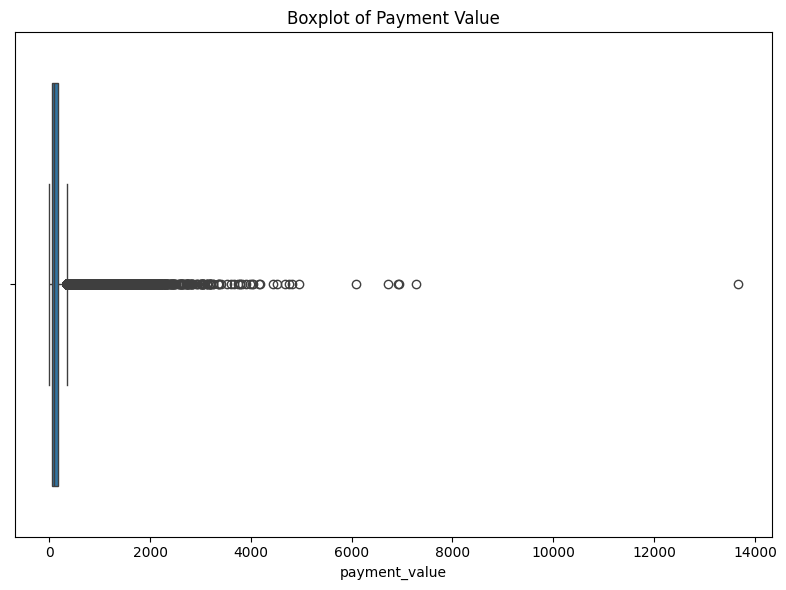

In [543]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=payments['payment_value'])
plt.title('Boxplot of Payment Value')
plt.xlabel('payment_value')
plt.tight_layout()
plt.show()

In [544]:
payments[payments['payment_value']>5000]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.54
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66


In [545]:
items.loc[items['order_id'] == '03caa2c082116e1d31e67e9ae3700499']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
1647,03caa2c082116e1d31e67e9ae3700499,1,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1648,03caa2c082116e1d31e67e9ae3700499,2,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1649,03caa2c082116e1d31e67e9ae3700499,3,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1650,03caa2c082116e1d31e67e9ae3700499,4,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1651,03caa2c082116e1d31e67e9ae3700499,5,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1652,03caa2c082116e1d31e67e9ae3700499,6,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1653,03caa2c082116e1d31e67e9ae3700499,7,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01
1654,03caa2c082116e1d31e67e9ae3700499,8,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,1680.0,28.01


Sum lại đúng giá trị cho nên mã 03caa2c082116e1d31e67e9ae3700499 không phải là error hay anomaly 

In [546]:
items.loc[items['order_id'] == '03caa2c082116e1d31e67e9ae3700499', ['price', 'freight_value']].sum()

price            13440.00
freight_value      224.08
dtype: float64

## Xuất file CSV

In [547]:
payments.to_csv(f'{out_dir}/cleaned_payments.csv', index=False)

# Customers

## Check data type

In [548]:
customers.dtypes

customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

## Check duplicate

In [549]:
customers[customers.duplicated()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


## Check null

In [550]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

## Xuất file CSV

In [551]:
customers.to_csv(f'{out_dir}/cleaned_customers.csv', index=False)

# Items

## Check data type

In [552]:
items.dtypes

order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

In [553]:
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])
items.dtypes

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

## Check duplicate

In [554]:
items[items.duplicated()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


## Check null

In [555]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## Check Outlier

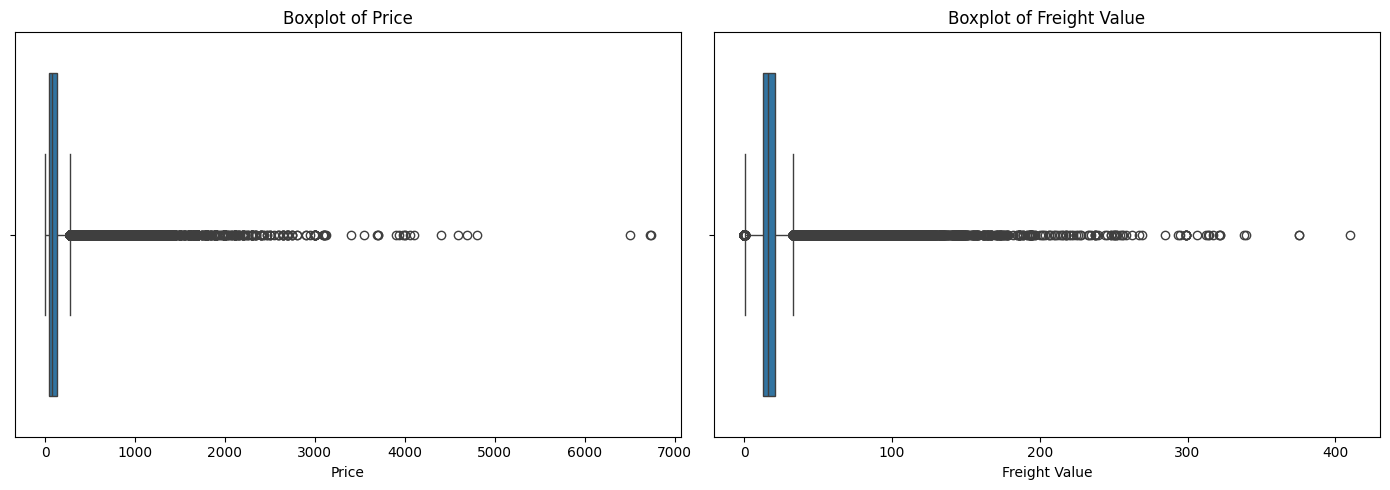

In [556]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=items['price'], ax=axes[0])
axes[0].set_title("Boxplot of Price")
axes[0].set_xlabel("Price")

sns.boxplot(x=items['freight_value'], ax=axes[1])
axes[1].set_title("Boxplot of Freight Value")
axes[1].set_xlabel("Freight Value")

plt.tight_layout()
plt.show()

Giá trị này bình thường

In [557]:
items[items["price"] > 5000]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21


Giá trị này bình thường có thể do đơn này freeship

In [558]:
items[items["freight_value"] == 0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.0
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:29,69.9,0.0
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:45,99.9,0.0
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
...,...,...,...,...,...,...,...
111094,fc698f330ec7fb74859071cc6cb29772,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-04-25 02:31:57,53.9,0.0
111497,fd4907109f6bac23f07064af84bec02d,1,7a10781637204d8d10485c71a6108a2e,4869f7a5dfa277a7dca6462dcf3b52b2,2018-04-30 11:31:32,219.0,0.0
111649,fd95e4b85ebbb81853d4a6be3d61432b,1,53b36df67ebb7c41585e8d54d6772e08,4869f7a5dfa277a7dca6462dcf3b52b2,2018-05-04 11:10:31,106.9,0.0
112182,fee19a0dc7358b6962a611cecf6a37b4,1,f1c7f353075ce59d8a6f3cf58f419c9c,37be5a7c751166fbc5f8ccba4119e043,2017-09-07 22:06:31,195.0,0.0


Giá trị outlier này cũng bình thường

In [559]:
items[items["freight_value"] > 300]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28
3584,0822bcde10bb5d023755a71bc8f7797f,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2018-05-10 23:52:39,990.00,321.46
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,2018-06-01 19:14:24,1050.00,321.88
6268,0e4672661531addf3fa0f55961e55242,1,dc861f18267cce21f3b70f9f7990b8ce,17f51e7198701186712e53a39c564617,2017-07-12 04:03:18,990.00,314.02
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30
27183,3dd5626c63f493f8b8f8788c2be24baa,1,3a1855685a49813f60e6193864f7215e,c510bc1718f0f2961eaa42a23330681a,2018-05-04 19:50:59,2699.00,306.06
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28
29787,43bdbd9dc0931d72befdf4765af6c442,1,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,2018-07-12 08:35:21,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-11-30 15:10:57,1045.00,314.40
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59


## Check data timeseries

Không có vấn đề hoặc chưa phát hiện ra vấn đề

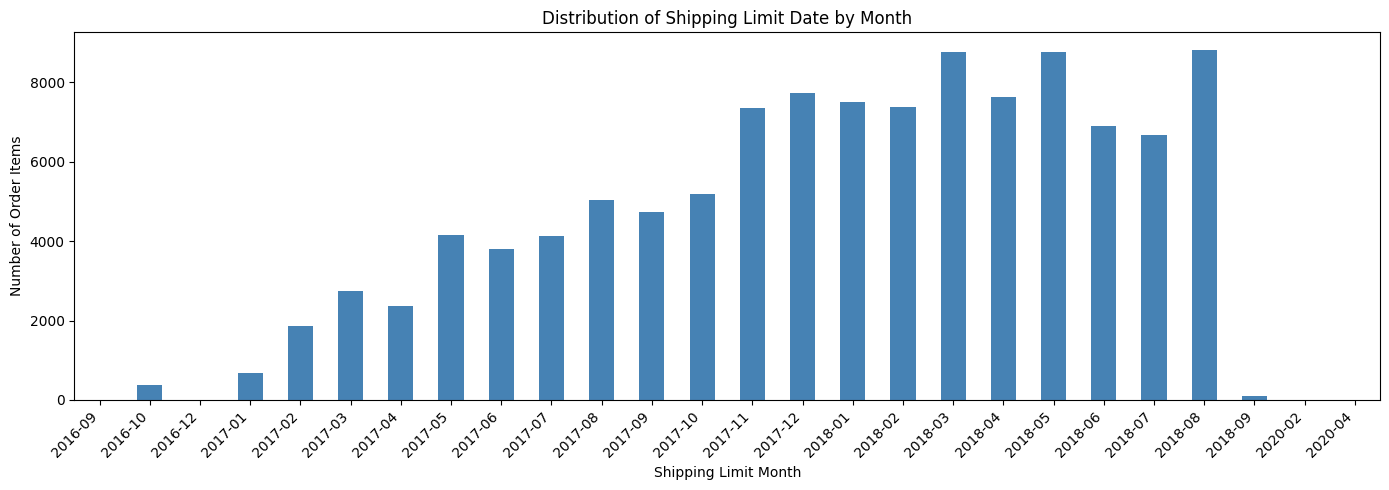

In [560]:
plt.figure(figsize=(14, 5))

# Đếm theo tháng và format YYYY-MM
monthly_counts = (
    items['shipping_limit_date']
    .dt.strftime('%Y-%m')
    .value_counts()
    .sort_index()
)

monthly_counts.plot(
    kind='bar',
    color='steelblue'
)

plt.title('Distribution of Shipping Limit Date by Month')
plt.xlabel('Shipping Limit Month')
plt.ylabel('Number of Order Items')

# Hiển thị đầy đủ YYYY-MM
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Xuất CSV

In [561]:
items.to_csv(f'{out_dir}/cleaned_items.csv', index=False)

# Products

## Check duplicate

In [562]:
products[products.duplicated()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


## Check data type

In [563]:
products.dtypes

product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

## Check Null

In [564]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

## Check outlier

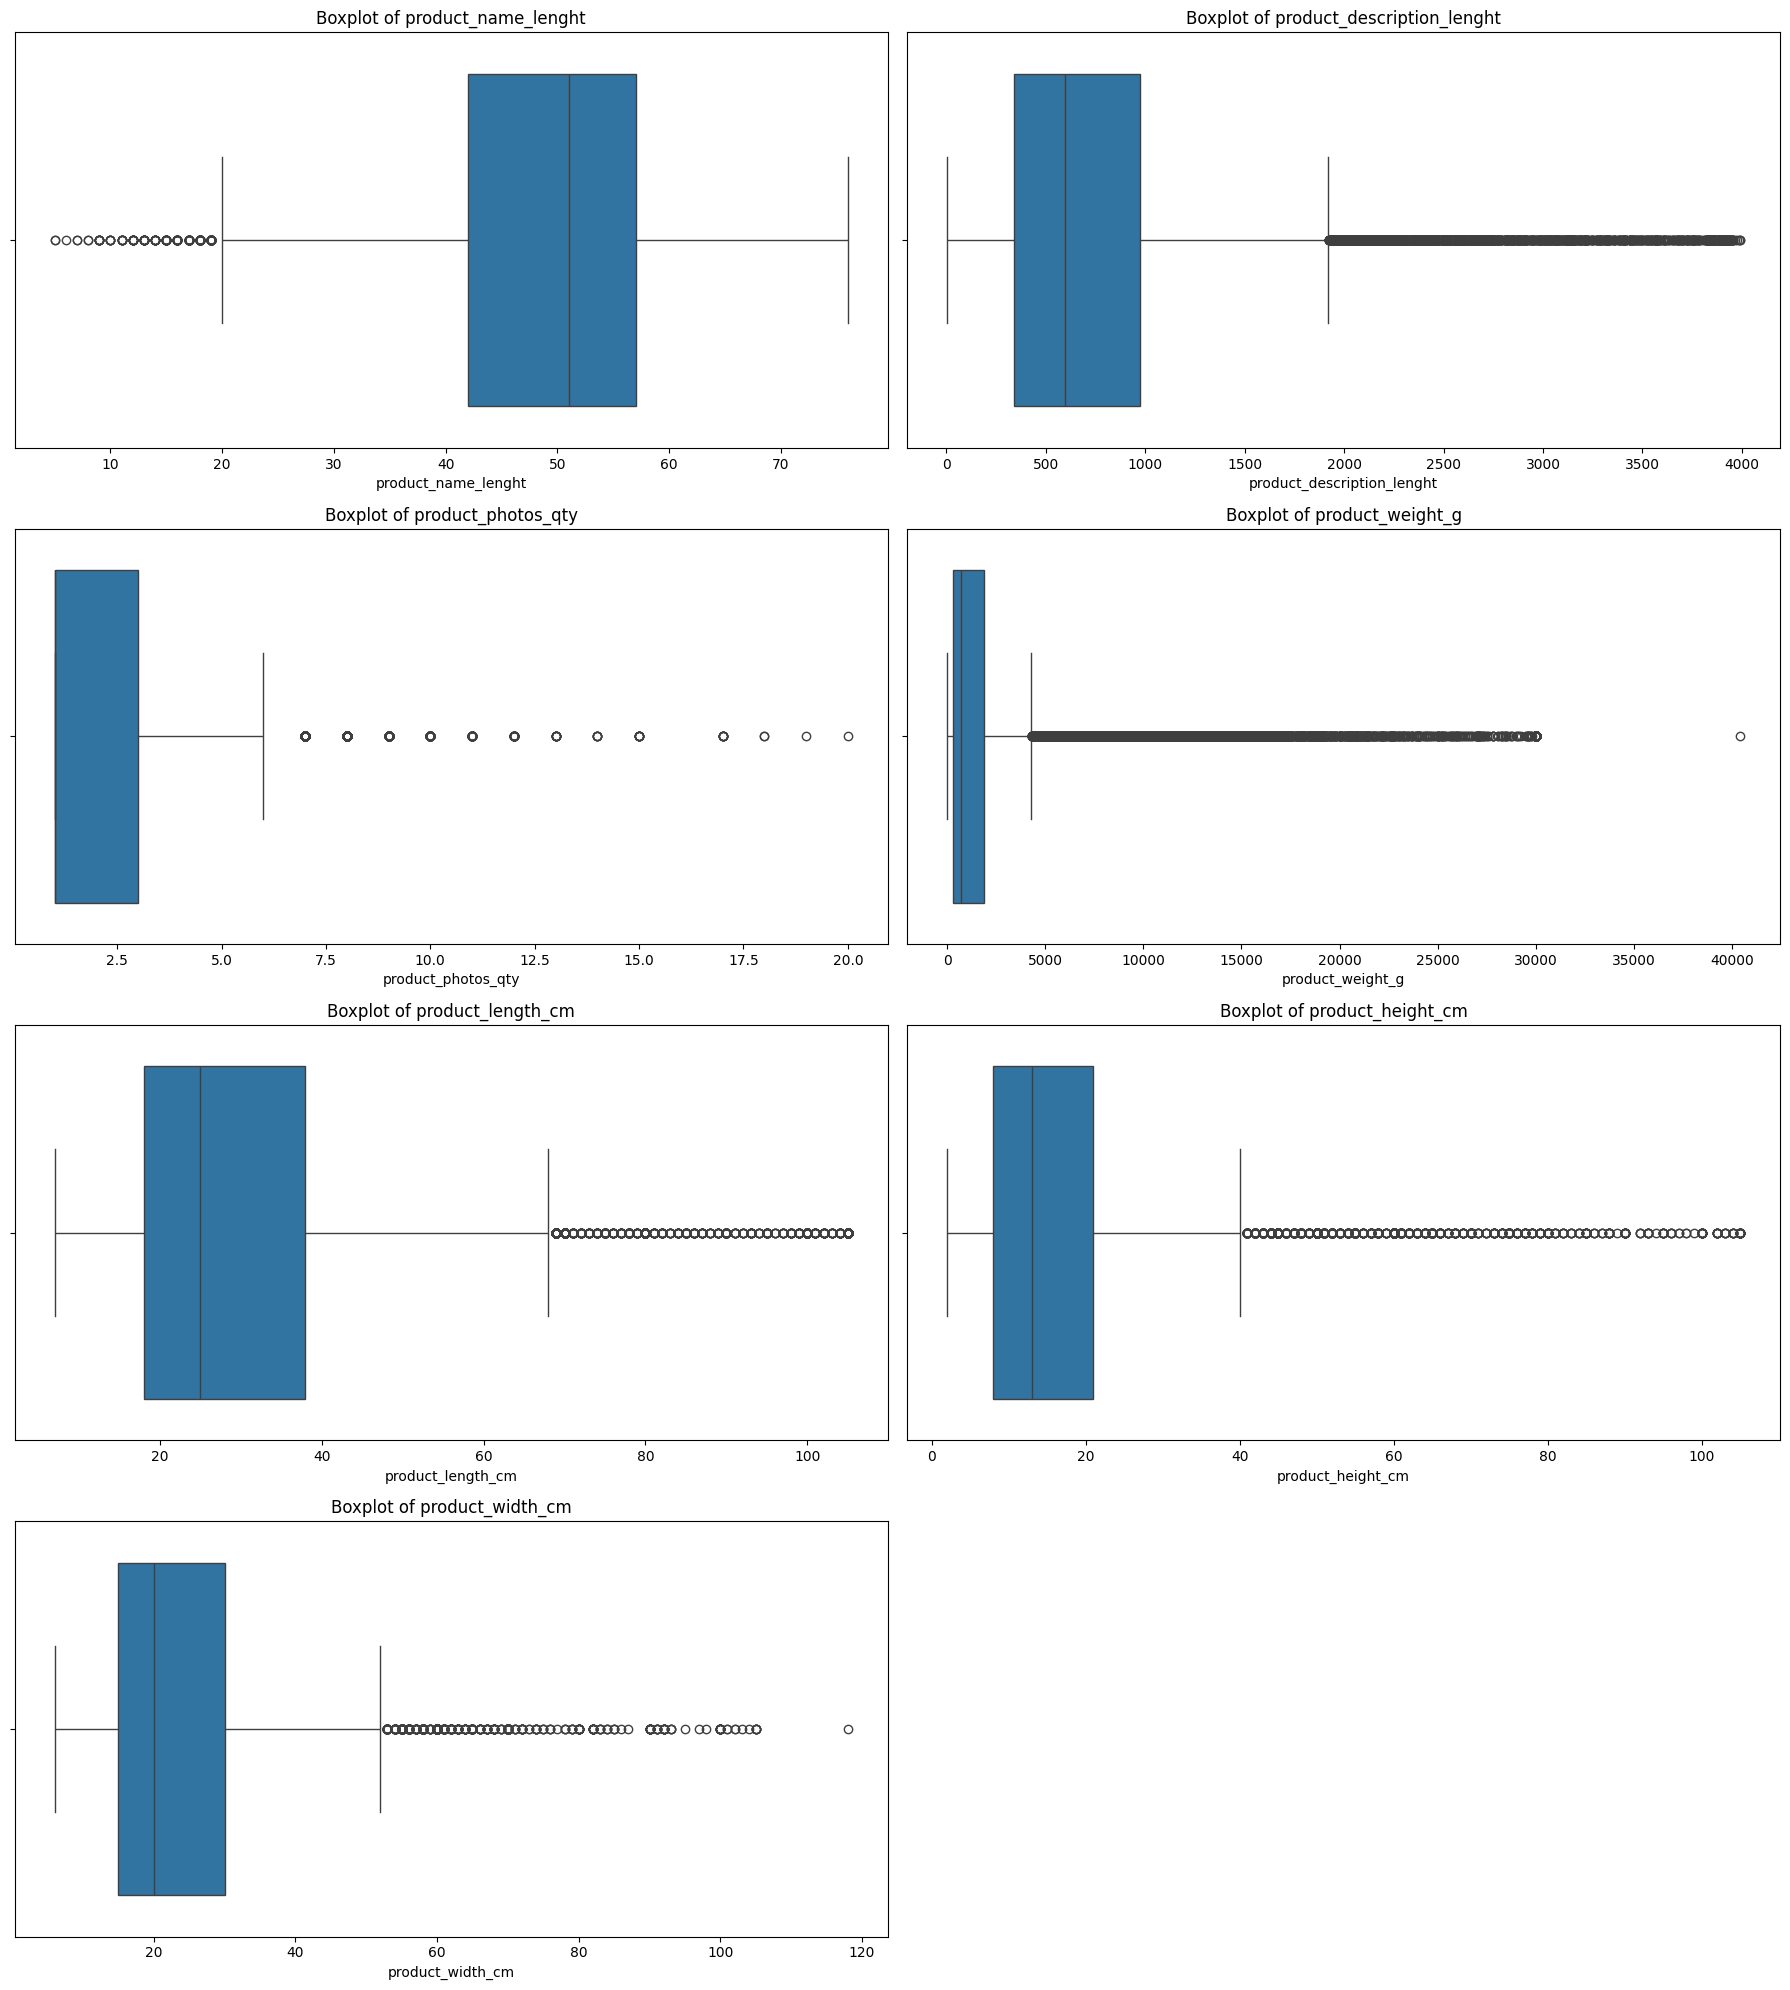

In [565]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x=products[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Xóa ô thừa
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Check outlier product_weight_g

In [566]:
products.loc[
    products['product_category_name'] == 'cama_mesa_banho',
    'product_weight_g'
].median()

np.float64(1250.0)

In [567]:
products.loc[
    products['product_weight_g'] > 30000,
    [
        'product_id',
        'product_category_name',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
]

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,40425.0,13.0,65.0,28.0


In [568]:
products[products['product_weight_g'] > 30000]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0


Với product_category_name cama_mesa_banho là bed_bath_table kích thước 13x65x28 mà weight 40425.0 g thì không hợp lý. Nghi vấn đây là anomaly

In [569]:
items[items["product_id"]=="26644690fde745fc4654719c3904e1db"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
32763,4a45f9f66971302cf881ecfa142f42ba,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2017-12-29 19:13:20,80.0,16.32
48753,6ecf1a4051b4c5ed613624b460970a26,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2017-11-23 08:55:48,80.0,12.06
63982,9223919b300f6989e1715333fca0d6ce,1,26644690fde745fc4654719c3904e1db,1835b56ce799e6a4dc4eddc053f04066,2018-03-07 23:15:32,80.0,16.32


Với weight cao như vậy mà price và freight_value thấp nên check với product có weight > 25000

In [570]:
products[products['product_weight_g'] > 25000]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
148,8d6cb00151d423c52855385c89f0bae8,automotivo,58.0,386.0,1.0,27100.0,50.0,50.0,50.0
344,d0877f0094337c414d23f5a3c7bad20c,moveis_escritorio,48.0,489.0,2.0,30000.0,50.0,50.0,30.0
509,53f92b0474f91fcb5bd188c6a8075c38,utilidades_domesticas,54.0,2952.0,3.0,30000.0,76.0,51.0,51.0
955,ceeba7d5636e59173cc5f484e913db3d,NaN,NaN,NaN,NaN,30000.0,65.0,65.0,65.0
1159,f97ad9066c718a6cef93dfcf253d3e0d,moveis_decoracao,63.0,886.0,5.0,30000.0,61.0,70.0,65.0
...,...,...,...,...,...,...,...,...,...
31654,3b85e44a54ca23950c469c7fb1cc0e0a,beleza_saude,42.0,1580.0,1.0,30000.0,30.0,88.0,22.0
32179,d7f8b7443f6ae5796dabe493521a1e79,industria_comercio_e_negocios,56.0,2029.0,2.0,30000.0,105.0,43.0,46.0
32262,ebf1c13032246ea801765e8cb5417365,casa_construcao,39.0,1190.0,2.0,30000.0,50.0,80.0,50.0
32491,2b752ed328ea866e4721ca4e236a416c,moveis_cozinha_area_de_servico_jantar_e_jardim,47.0,2201.0,4.0,30000.0,16.0,2.0,11.0


In [571]:
items[items["product_id"]=="f97ad9066c718a6cef93dfcf253d3e0d"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
105386,ef6572468642ad6f224c1991a17bc4a6,1,f97ad9066c718a6cef93dfcf253d3e0d,11305281b50fff20ae8bb473f8e11876,2017-12-08 20:35:22,399.99,113.38


In [572]:
items[items["product_id"]=="d0877f0094337c414d23f5a3c7bad20c"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
9708,163f8eb1b8e1a57c3ff383c09e13d42c,1,d0877f0094337c414d23f5a3c7bad20c,656591be56071d4c9ef4e5fee78a578a,2017-04-19 16:10:10,430.0,45.47
94703,d6c877d8995925578fdeb1d186915549,1,d0877f0094337c414d23f5a3c7bad20c,656591be56071d4c9ef4e5fee78a578a,2017-05-11 13:10:37,430.0,27.52


Với weight > 25000 thường thì price và freight_value sẽ cao nên kết luận product 26644690fde745fc4654719c3904e1db weight product_weight_g = 40425.0
có thể là anomaly. Hướng xử lý điền meadian product_weight_g theo product_category_name	cama_mesa_banho

In [573]:
median_weight = products.loc[
    (products["product_category_name"] == "cama_mesa_banho") &
    (products["product_weight_g"] != 40425.0),
    "product_weight_g"
].median()

products.loc[
    products["product_weight_g"] == 40425.0,
    "product_weight_g"
] = median_weight

In [574]:
products[products["product_id"]=="26644690fde745fc4654719c3904e1db"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,1250.0,13.0,65.0,28.0


Check outlier product_width_cm

Giá trị này product_width_cm = 118 là bình thường

In [575]:
products[products['product_width_cm'] > 110]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
26970,b17808303e15dd50538c011b44295427,cama_mesa_banho,56.0,502.0,3.0,1050.0,23.0,93.0,118.0


Check outlier product_photos_qty

In [576]:
products[products['product_photos_qty'] > 15]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
967,f9aa001a859b11fd798bb386f3d07eb0,pet_shop,54.0,802.0,17.0,9000.0,33.0,30.0,44.0
2112,26f4f1d683f32cfce93292cc626d5eea,pet_shop,53.0,823.0,17.0,1150.0,21.0,17.0,30.0
2196,7f38cf4e517ec6bb1d31c4e6b6df18ef,pet_shop,56.0,834.0,17.0,2000.0,33.0,30.0,44.0
9022,f95d5d21561ea085ba1e1a4e53840844,brinquedos,62.0,679.0,20.0,8900.0,32.0,49.0,34.0
11009,28763a4fd1b597a9c4f31a9579e7d1b4,pet_shop,53.0,823.0,17.0,1150.0,21.0,17.0,30.0
15735,801f0a5ea1ac28df44d65195cf4e2620,pet_shop,56.0,834.0,17.0,7300.0,33.0,30.0,44.0
17843,e9880042522806f124fdd4f8c8514d0d,pet_shop,54.0,830.0,18.0,2600.0,33.0,30.0,44.0
19056,234495ab7809d4517bc1330c439da1bb,bebes,63.0,659.0,19.0,8900.0,32.0,49.0,34.0
22005,5948868c402a614a2dd3b90ebb06a253,pet_shop,53.0,795.0,17.0,1100.0,21.0,17.0,30.0
24522,b085d8c8840e8dd3d6ccdf3d86c6145e,pet_shop,53.0,823.0,17.0,1050.0,21.0,17.0,30.0


Giá trị này bình thường

## Check correlation missing theo cặp các biến

<Axes: >

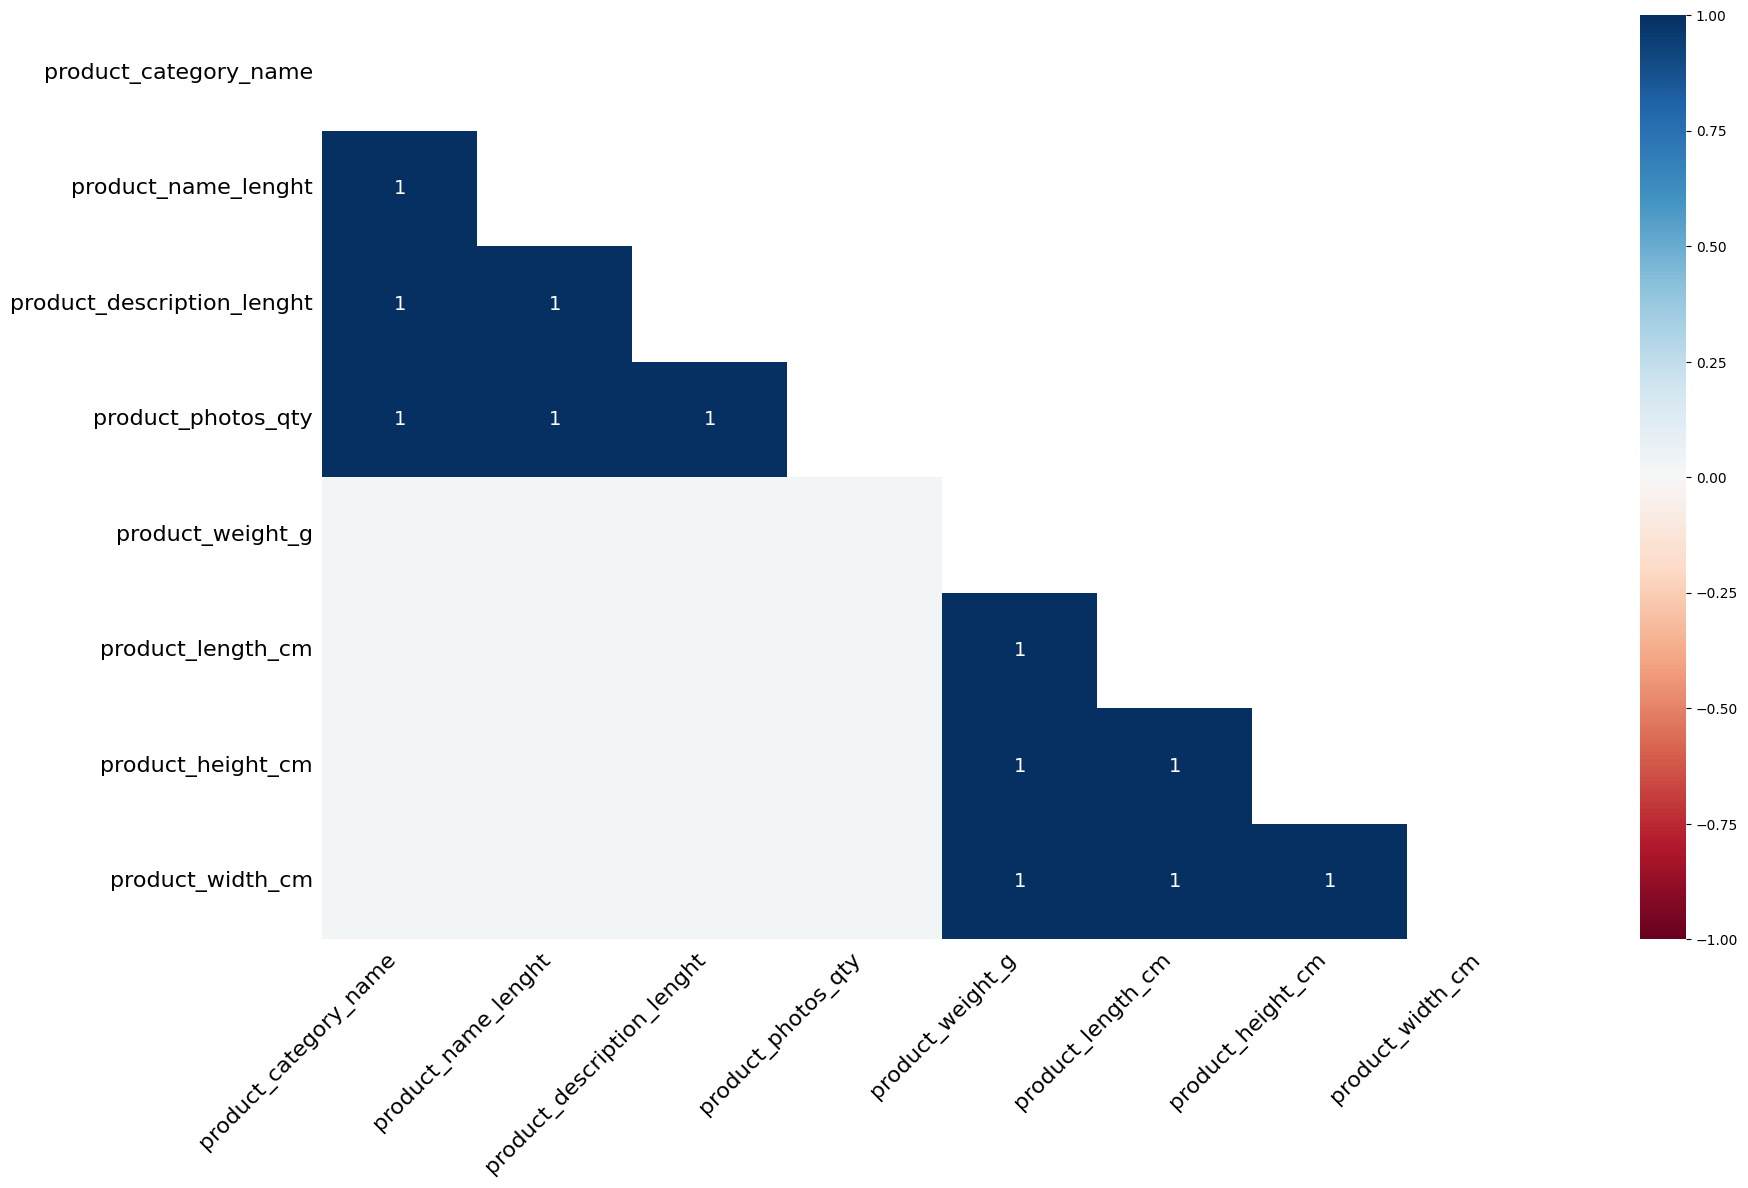

In [577]:
msno.heatmap(products)

## Check correlation missing nhóm các biến

<Axes: >

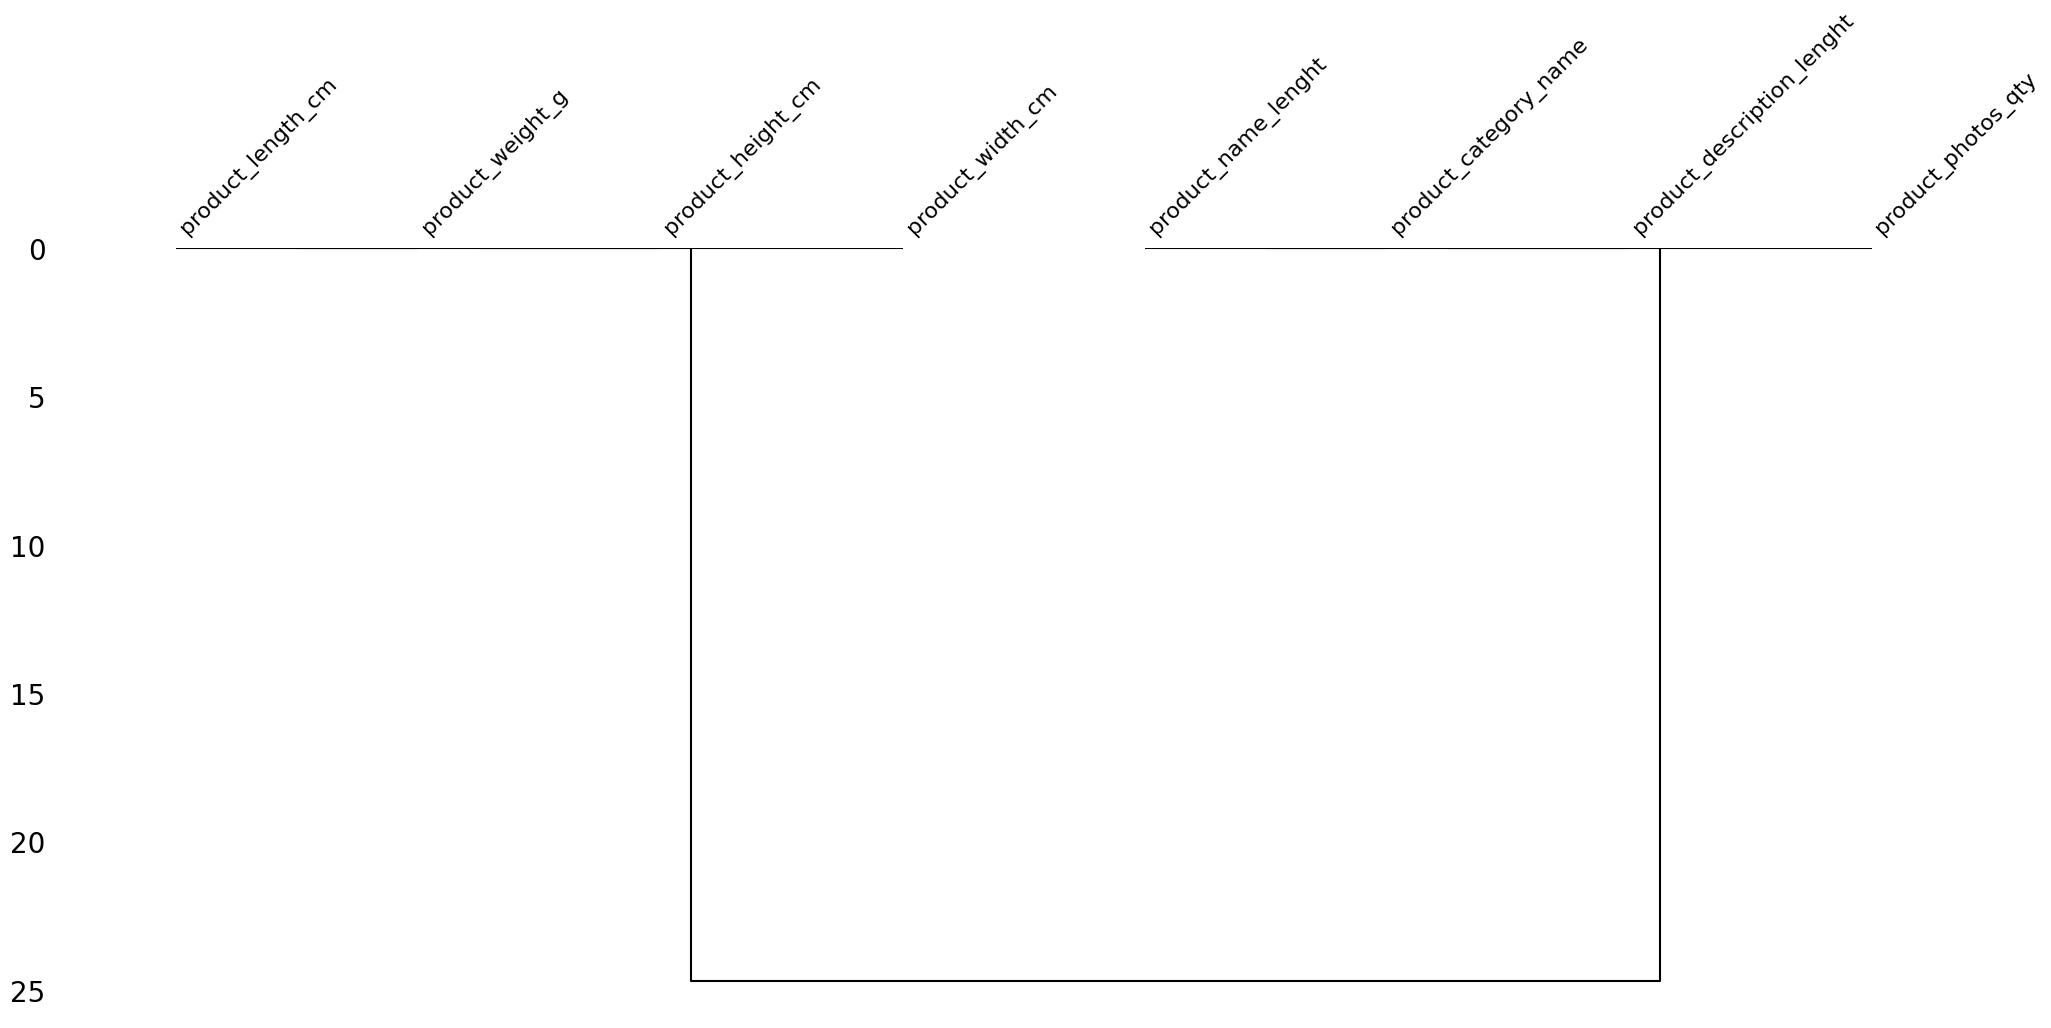

In [578]:
products_drop_id = products.drop(columns=["product_id"], inplace=False)

msno.dendrogram(products_drop_id)

Kết luận: 
Missing theo pattern correlation = 1 giữa các cặp biến khẳng định biến này missing thì biến kia cũng missing

Pattern 1: product_weight_g	product_length_cm	product_height_cm	product_width_cm

Pattern 2: product_category_name	product_name_lenght	product_description_lenght	product_photos_qty	

## Check pattern 2

In [579]:
products[products["product_length_cm"].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Mã 5eb564652db742ff8f28759cd8d2652a	 missing type là Unit nonresponse không drop được vì nếu drop sẽ mất đi nhiều item

In [580]:
items[items["product_id"]=="5eb564652db742ff8f28759cd8d2652a"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7098,101157d4fae1c9fb74a00a5dee265c25,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 08:02:26,29.0,14.52
9233,1521c6bb7b1028154c8c67cf80fa809f,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:10:16,29.0,16.05
28715,415cfaaaa8cea49f934470548797fed1,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
28716,415cfaaaa8cea49f934470548797fed1,2,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
39299,595316a07cd3dea9db7adfcc7e247ae7,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-18 04:26:04,39.0,9.27
48424,6e150190fbe04c642a9cf0b80d83ee16,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-06-30 16:45:14,39.0,16.79
48980,6f497c40431d5fb0cfbd6c943dd29215,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 05:55:32,29.0,10.96
71134,a2456e7f02197951664897a94c87242d,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-06 11:50:09,29.0,24.84
73556,a7a43f469c0d7bdb0a23a82db125aefa,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-28 13:15:11,39.0,15.10
82767,bbfc7badbed2f1828e22b6d629201bd4,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-07-18 04:04:10,39.0,11.85


Hướng xử lý điền Unknown cho category điền 0 cho numerical

In [581]:
products.loc[
    products["product_id"] == "5eb564652db742ff8f28759cd8d2652a",
    [
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
] = ["Unknown", 0, 0, 0, 0, 0, 0, 0]

In [582]:
products[products["product_id"]=="5eb564652db742ff8f28759cd8d2652a"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18851,5eb564652db742ff8f28759cd8d2652a,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Mã 09ff539a621711667c43eba6a3bd8466 hướng xử lý impute theo meadian của các biến này

In [583]:
products[products["product_id"]=="09ff539a621711667c43eba6a3bd8466"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN


In [584]:
cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

medians = products.loc[
    products["product_category_name"] == "bebes",
    cols
].median()

products.loc[
    products["product_id"] == "09ff539a621711667c43eba6a3bd8466",
    cols
] = products.loc[
    products["product_id"] == "09ff539a621711667c43eba6a3bd8466",
    cols
].fillna(medians)

In [585]:
products[products["product_id"]=="09ff539a621711667c43eba6a3bd8466"]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,850.0,33.0,16.0,25.0


## Check pattern 1

In [586]:
missing_products = products[
    products[
        [
            "product_category_name",
            "product_name_lenght",
            "product_description_lenght",
            "product_photos_qty"
        ]
    ].isna().all(axis=1)
]

In [587]:
missing_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


Chiến lược impute nếu 

Với mỗi row bị missing ở:

product_category_name

product_name_lenght

product_description_lenght

product_photos_qty

Bạn dùng 4 biến:

product_weight_g

product_length_cm

product_height_cm

product_width_cm


để tìm các row giống hệt trong products.

Sau đó:

Nếu cột cần impute chỉ có đúng 1 unique value

→ impute giá trị đó.

Nếu có từ 2 unique value trở lên

→ không impute vì ambiguous.

Mục tiêu là impute Category có thể

ví dụ

In [588]:
products[
    (products['product_weight_g'] == 300.0) &
    (products['product_length_cm'] == 16.0) &
    (products['product_height_cm'] == 7.0) &
    (products['product_width_cm'] == 20.0)
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
11283,8d98dedc3c19de17f1a090195e85d6b6,brinquedos,40.0,617.0,4.0,300.0,16.0,7.0,20.0
29248,2f9c82f3ca3b33585ac101579a28933d,brinquedos,44.0,687.0,4.0,300.0,16.0,7.0,20.0


In [589]:
cols_match = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

cols_impute = [
    "product_category_name",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

for idx, row in missing_products.iterrows():

    # tìm các record có cùng weight + dimensions
    matched = products[
        (products["product_weight_g"] == row["product_weight_g"]) &
        (products["product_length_cm"] == row["product_length_cm"]) &
        (products["product_height_cm"] == row["product_height_cm"]) &
        (products["product_width_cm"] == row["product_width_cm"])
    ]

    for col in cols_impute:

        # lấy unique value, bỏ NaN
        unique_vals = matched[col].dropna().unique()

        # chỉ impute nếu unique value = 1
        if len(unique_vals) == 1:
            products.loc[idx, col] = unique_vals[0]

In [590]:
products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [591]:
products[
    (products['product_weight_g'] == 300.0) &
    (products['product_length_cm'] == 16.0) &
    (products['product_height_cm'] == 7.0) &
    (products['product_width_cm'] == 20.0)
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
128,d8dee61c2034d6d075997acef1870e9b,brinquedos,NaN,NaN,4.0,300.0,16.0,7.0,20.0
11283,8d98dedc3c19de17f1a090195e85d6b6,brinquedos,40.0,617.0,4.0,300.0,16.0,7.0,20.0
29248,2f9c82f3ca3b33585ac101579a28933d,brinquedos,44.0,687.0,4.0,300.0,16.0,7.0,20.0


In [592]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.00
product_category_name         1.65
product_name_lenght           1.68
product_description_lenght    1.68
product_photos_qty            1.64
product_weight_g              0.00
product_length_cm             0.00
product_height_cm             0.00
product_width_cm              0.00
dtype: float64

Còn lại điền unknown category

In [593]:
products["product_category_name"] = (
    products["product_category_name"]
    .fillna("Unknown")
)

In [594]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.00
product_category_name         0.00
product_name_lenght           1.68
product_description_lenght    1.68
product_photos_qty            1.64
product_weight_g              0.00
product_length_cm             0.00
product_height_cm             0.00
product_width_cm              0.00
dtype: float64

Còn lại thì impute theo meadian hoặc thuật toán hoặc không impute

Impute meadian theo product_category_name 

In [595]:
cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

products[cols] = (
    products.groupby("product_category_name")[cols]
    .transform(lambda x: x.fillna(x.median()))
)

In [596]:
(products.isnull().sum() / len(products) * 100).round(2)

product_id                    0.0
product_category_name         0.0
product_name_lenght           0.0
product_description_lenght    0.0
product_photos_qty            0.0
product_weight_g              0.0
product_length_cm             0.0
product_height_cm             0.0
product_width_cm              0.0
dtype: float64

## So sánh distribution trước và sau impute

In [597]:
products_origin = pd.read_csv(products_file_path)

In [598]:
cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

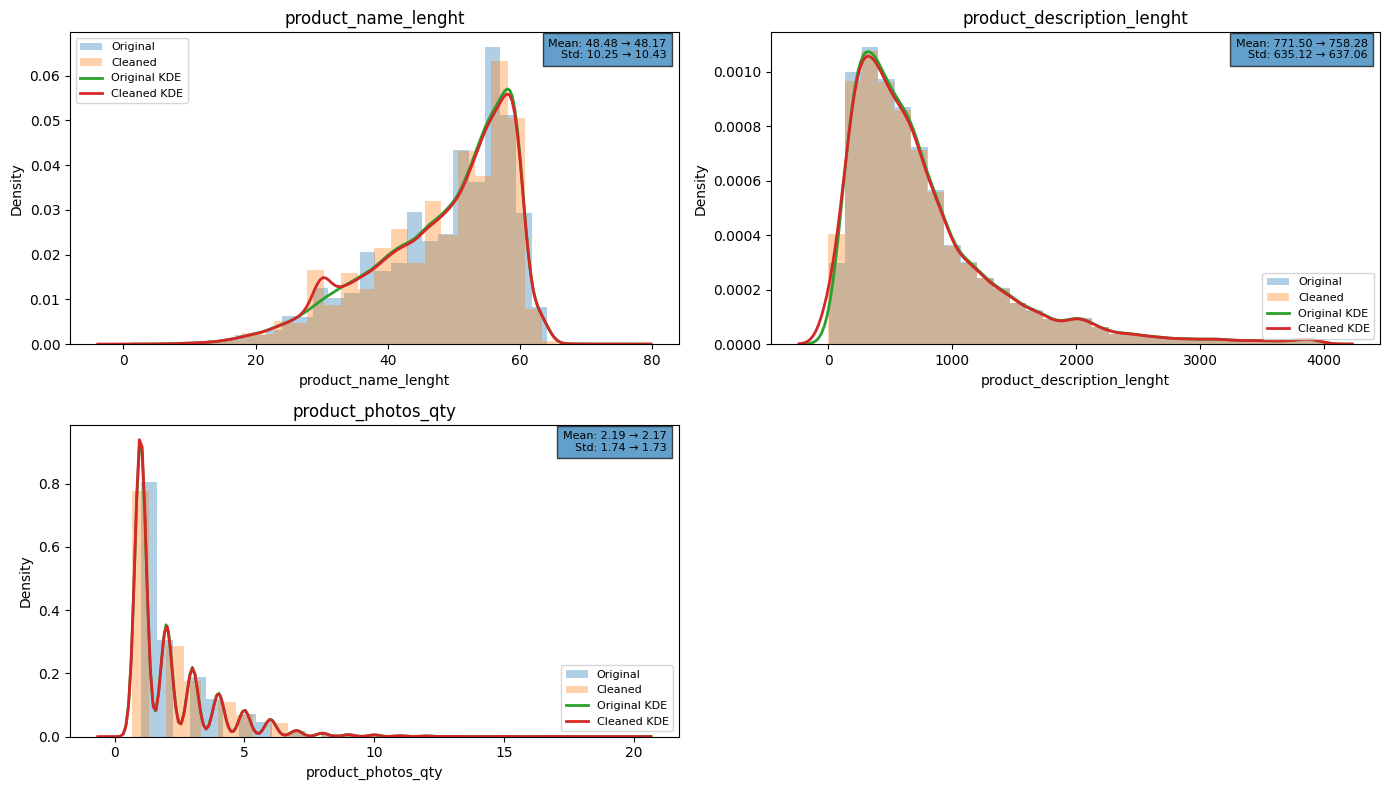

In [599]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

n_cols = 2
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cols):

    original = products_origin[col].dropna()
    cleaned = products[col].dropna()

    ax = axes[i]

    # Histogram
    ax.hist(
        original,
        bins=30,
        alpha=0.35,
        density=True,
        label="Original"
    )

    ax.hist(
        cleaned,
        bins=30,
        alpha=0.35,
        density=True,
        label="Cleaned"
    )

    # KDE
    sns.kdeplot(
        original,
        ax=ax,
        linewidth=2,
        label="Original KDE"
    )

    sns.kdeplot(
        cleaned,
        ax=ax,
        linewidth=2,
        label="Cleaned KDE"
    )

    # Thống kê
    original_mean = original.mean()
    cleaned_mean = cleaned.mean()

    original_std = original.std()
    cleaned_std = cleaned.std()

    txt = (
        f"Mean: {original_mean:.2f} → {cleaned_mean:.2f}\n"
        f"Std: {original_std:.2f} → {cleaned_std:.2f}"
    )

    ax.text(
        0.98,
        0.98,
        txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(alpha=0.7)
    )

    ax.set_title(col)
    ax.legend(fontsize=8)

# Xóa subplot thừa
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

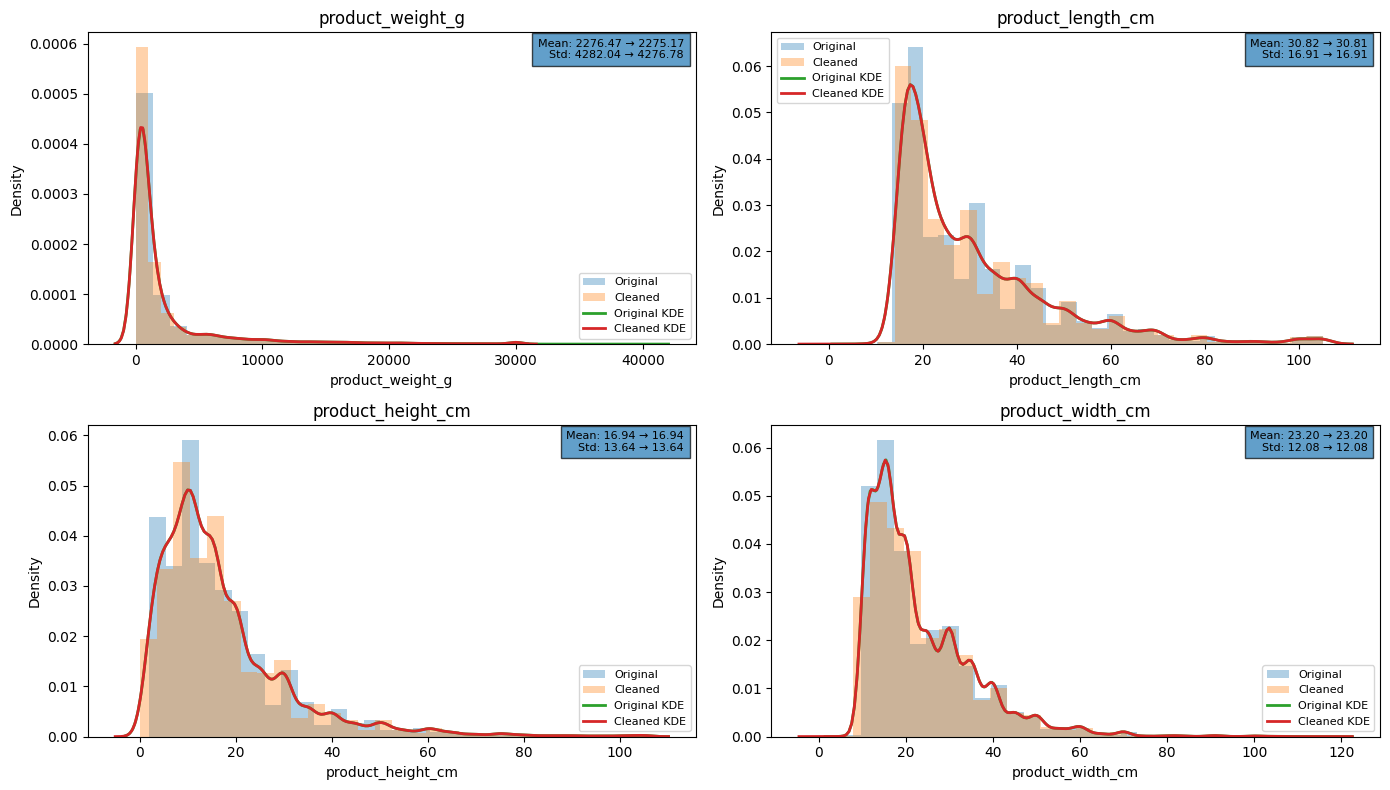

In [600]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cols = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

n_cols = 2
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cols):

    original = products_origin[col].dropna()
    cleaned = products[col].dropna()

    ax = axes[i]

    # Histogram
    ax.hist(
        original,
        bins=30,
        alpha=0.35,
        density=True,
        label="Original"
    )

    ax.hist(
        cleaned,
        bins=30,
        alpha=0.35,
        density=True,
        label="Cleaned"
    )

    # KDE
    sns.kdeplot(
        original,
        ax=ax,
        linewidth=2,
        label="Original KDE"
    )

    sns.kdeplot(
        cleaned,
        ax=ax,
        linewidth=2,
        label="Cleaned KDE"
    )

    # Thống kê
    original_mean = original.mean()
    cleaned_mean = cleaned.mean()

    original_std = original.std()
    cleaned_std = cleaned.std()

    txt = (
        f"Mean: {original_mean:.2f} → {cleaned_mean:.2f}\n"
        f"Std: {original_std:.2f} → {cleaned_std:.2f}"
    )

    ax.text(
        0.98,
        0.98,
        txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(alpha=0.7)
    )

    ax.set_title(col)
    ax.legend(fontsize=8)

# Xóa subplot thừa
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

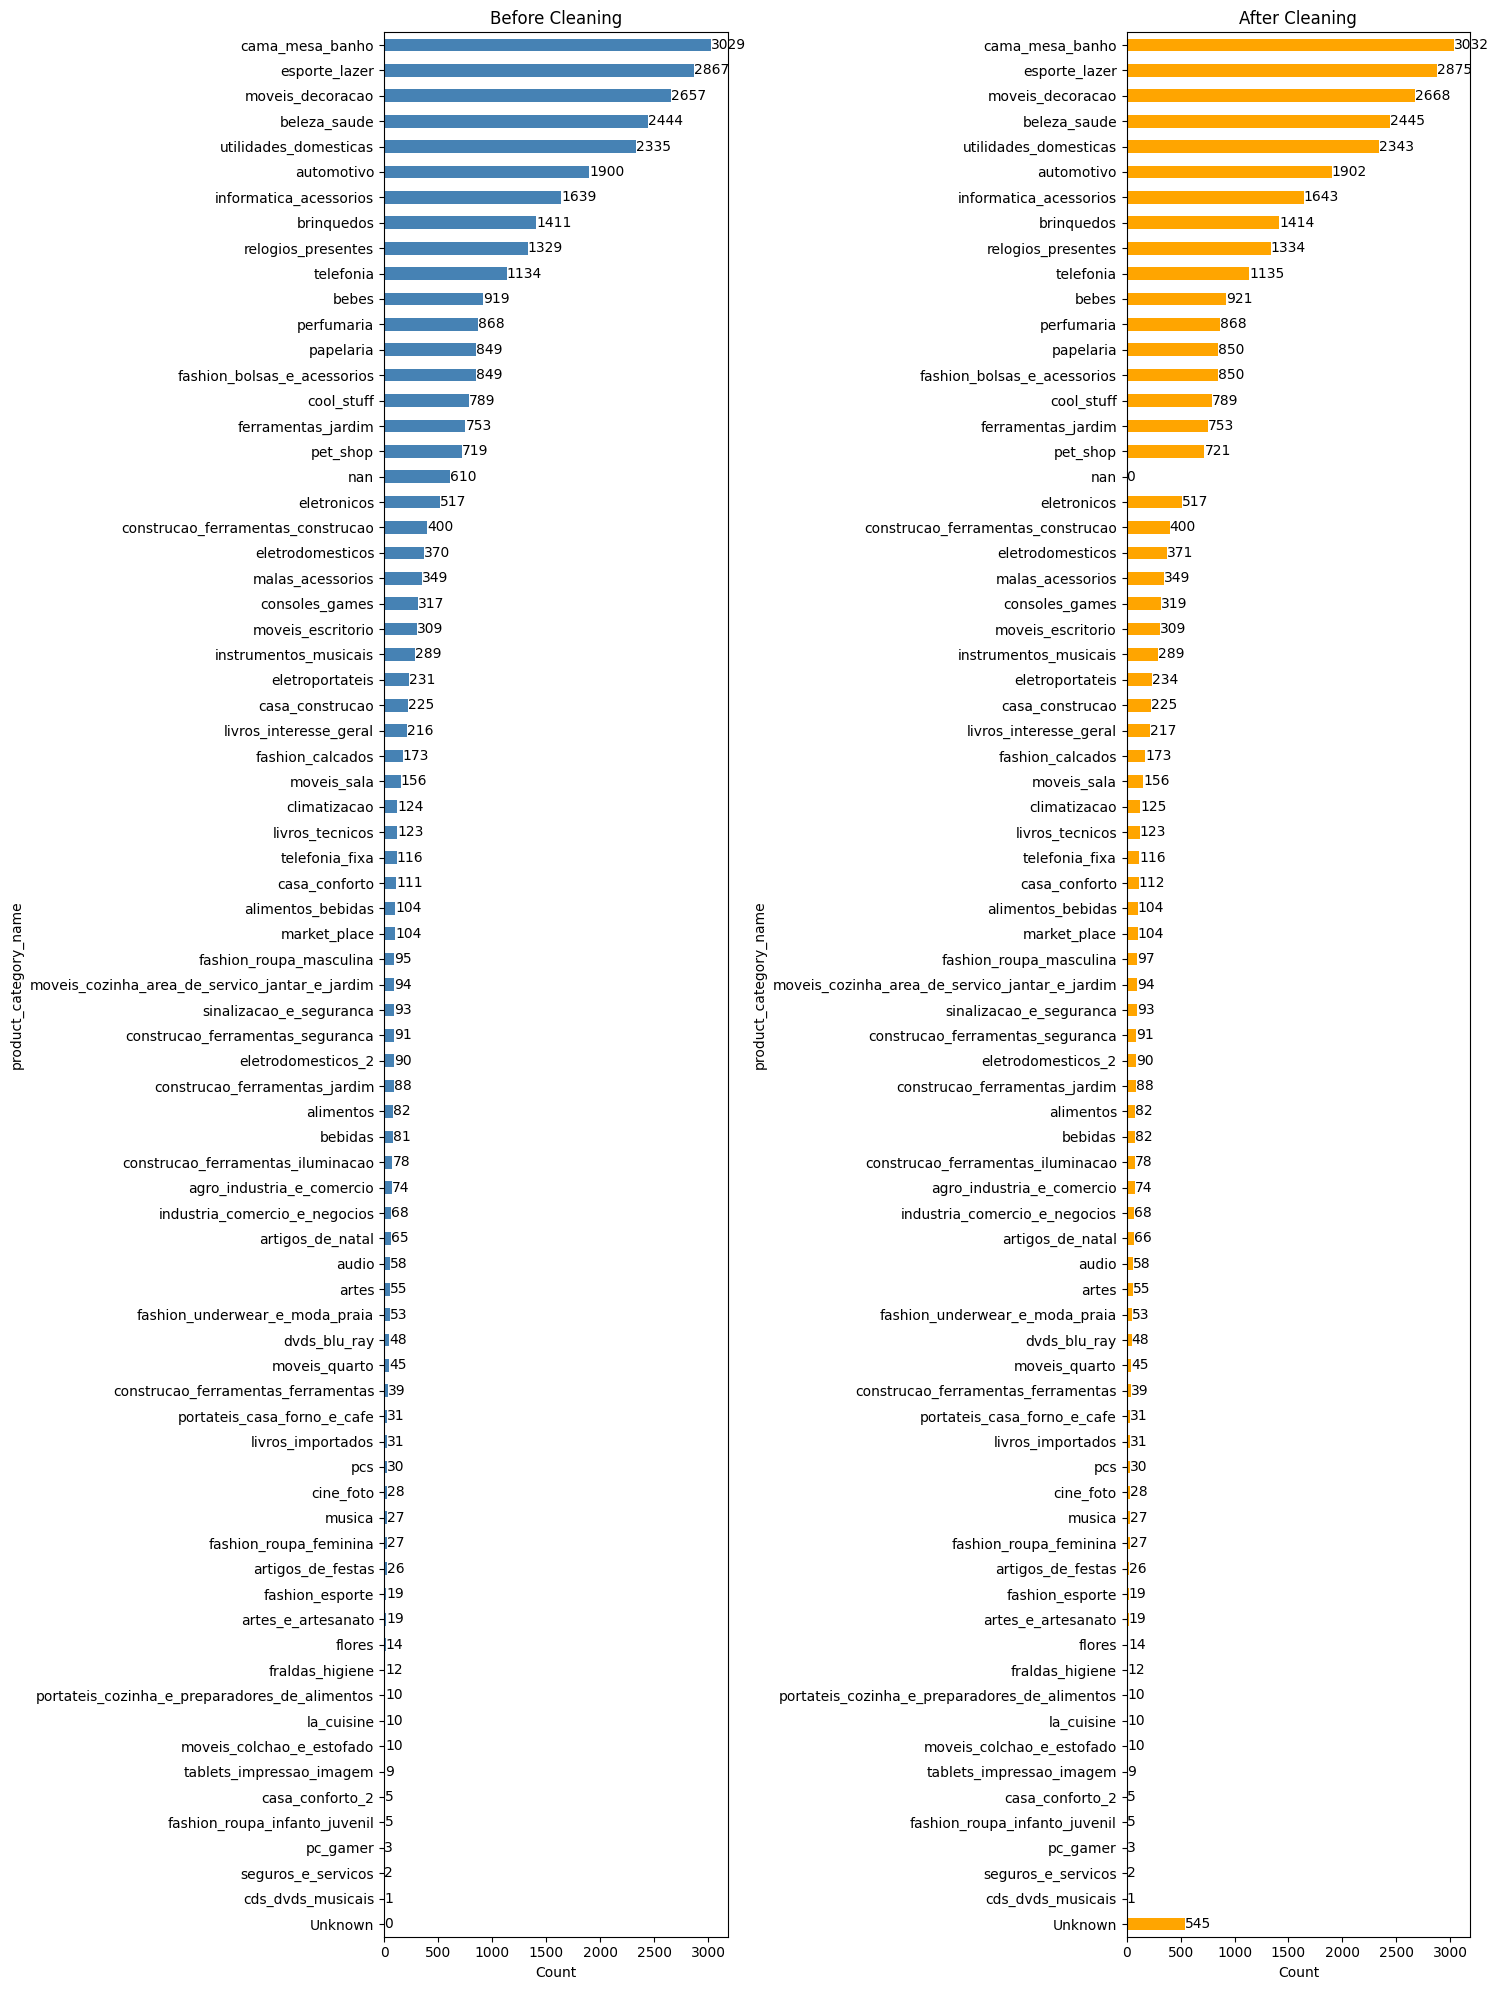

In [601]:
import matplotlib.pyplot as plt
import pandas as pd

before = products_origin["product_category_name"].value_counts(dropna=False)
after_cleaned = products["product_category_name"].value_counts(dropna=False)

df_plot = pd.DataFrame({
    "Before": before,
    "After Cleaned": after_cleaned
}).fillna(0)

df_plot = df_plot.sort_values("Before")

fig, axes = plt.subplots(1, 2, figsize=(15, 20))

# BEFORE
df_plot["Before"].plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("Count")

axes[0].bar_label(
    axes[0].containers[0],
    fmt="%.0f"
)

# AFTER CLEANED
df_plot["After Cleaned"].plot(
    kind="barh",
    ax=axes[1],
    color="orange"
)

axes[1].set_title("After Cleaning")
axes[1].set_xlabel("Count")

axes[1].bar_label(
    axes[1].containers[0],
    fmt="%.0f"
)

plt.tight_layout()
plt.show()

Nhận xét: 
Tổng quan:

Imputation đã bảo toàn khá tốt phân phối của hầu hết các biến, không gây biến dạng lớn.

Chi tiết từng biến:
product_category_name: không làm phá vỡ cấu trúc category

product_name_length: Rất tốt. Phân phối trước/sau gần như trùng nhau, chỉ mượt hơn một chút ở vùng peak (~55-60).

product_description_length: Tốt. Vẫn giữ nguyên hình dạng right-skew mạnh. Imputed bổ sung thêm một ít ở vùng giá trị rất thấp (gần 0).

product_photos_qty: Tốt. Giữ nguyên tính discrete và peak mạnh ở 0-1 ảnh.

product_weight_g: Tốt. Vẫn giữ right-skew cực mạnh. Imputed thêm một ít mật độ ở vùng trọng lượng rất nhẹ.

product_length_cm, height_cm, width_cm: Tất cả đều tốt.

Phân phối trước và sau rất giống nhau.

Peak chính (~15-25cm) được giữ nguyên.

Imputed làm mượt histogram hơn, không làm lệch shape đáng kể.

## Xuất file csv

In [602]:
import os

os.makedirs(out_dir, exist_ok=True)
products.to_csv(os.path.join(out_dir, "cleaned_products.csv"), index=False)

# Orders

## Check data type

In [603]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [604]:
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## Check null

In [605]:
(orders.isnull().sum() / len(orders) * 100).round(2)

order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
order_estimated_delivery_date    0.00
dtype: float64

### Check null theo order_status

In [606]:
# Kiểm tra tỷ lệ thiếu hụt theo từng trạng thái đơn hàng để đưa ra quyết định xử lý
missing_by_status = orders.groupby('order_status').apply(lambda x: x.isnull().mean() * 100)
cols_with_missing = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
missing_by_status[cols_with_missing]

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0.000000,100.000000,100.000000
canceled,22.560000,88.000000,99.040000
created,100.000000,100.000000,100.000000
delivered,0.014511,0.002073,0.008292
invoiced,0.000000,100.000000,100.000000
processing,0.000000,100.000000,100.000000
shipped,0.000000,0.000000,100.000000
unavailable,0.000000,100.000000,100.000000


Nhận xét: 
Missing phụ thuộc mạnh vào biến order_status => MAR

Trạng thái created: Giai đoạn này hệ thống chưa sinh timestamp order_approved_at, order_delivered_carrier_date, order_delivered_customer_date nên 100% missing

Trạng thái approved: Giai đoạn này hệ thống sinh timestamp order_approved_at chưa sinh timestamp order_delivered_carrier_date, order_delivered_customer_date nên 100% missing

Trạng thái invoiced, processing, unavailable: Giai đoạn này hệ thống chưa sinh timestamp order_delivered_carrier_date, order_delivered_customer_date nên 100% missing

Trạng thái shipped: Giai đoạn này hệ thống sinh timestamp order_delivered_carrier_date chưa sinh timestamp order_delivered_customer_date nên 100% missing

Trạng thái delivered: Giai đoạn này hệ thống đã sinh hết các timestamp rồi nhưng vẫn tồn tại missing cần phải xem xét.

Trạng thái canceled: Khó xử lý nhất vì không biết đơn hàng bị canceled ở giai đoạn nào

## Check outlier

### Tính Delay

In [607]:
# 1. Thời gian duyệt đơn hàng
orders['approval_delay'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600

# 2. Thời gian chuẩn bị hàng và giao cho nhà vận chuyển
orders['carrier_delay'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / 3600

# 3. Thời gian vận chuyển đến tay khách hàng
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.total_seconds() / 3600

### Boxplot

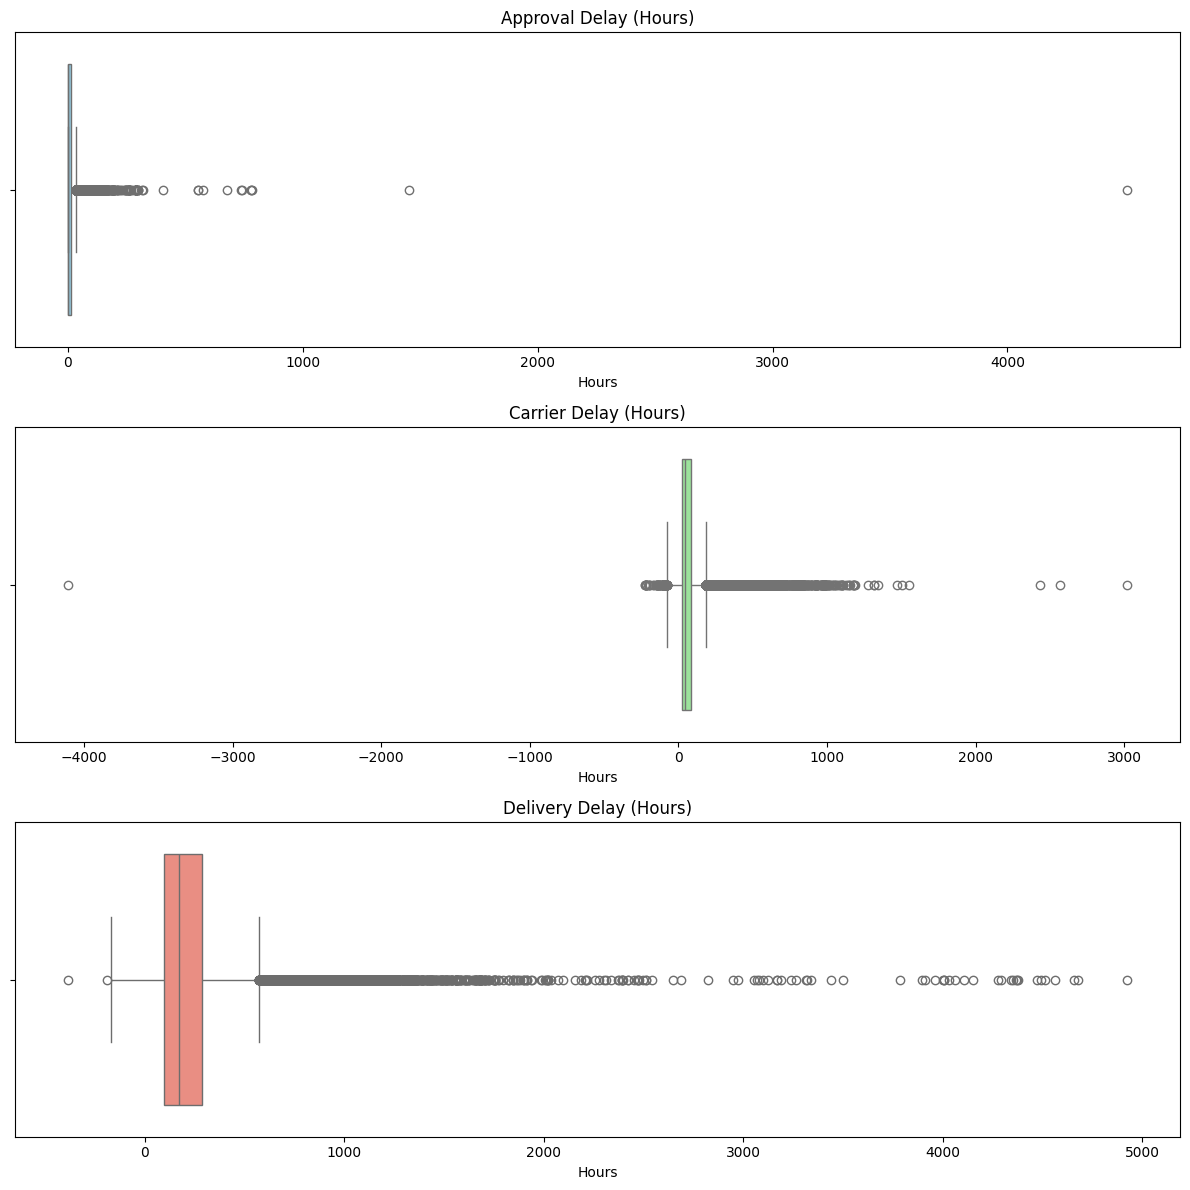

In [608]:
# Thiết lập layout cho 3 biểu đồ nằm dọc (vì boxplot ngang cần không gian chiều dọc)
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# 1. Boxplot ngang cho Approval Delay
sns.boxplot(ax=axes[0], x=orders['approval_delay'].dropna(), color='skyblue', orient='h')
axes[0].set_title('Approval Delay (Hours)')
axes[0].set_xlabel('Hours')

# 2. Boxplot ngang cho Carrier Delay
sns.boxplot(ax=axes[1], x=orders['carrier_delay'].dropna(), color='lightgreen', orient='h')
axes[1].set_title('Carrier Delay (Hours)')
axes[1].set_xlabel('Hours')

# 3. Boxplot ngang cho Delivery Delay
sns.boxplot(ax=axes[2], x=orders['delivery_delay'].dropna(), color='salmon', orient='h')
axes[2].set_title('Delivery Delay (Hours)')
axes[2].set_xlabel('Hours')

plt.tight_layout()
plt.show()

### Tính toán các chỉ số của boxplot

In [609]:
# Tính toán các chỉ số thống kê chi tiết (boxplot stats) cho các loại delay
delay_columns = ['approval_delay', 'carrier_delay', 'delivery_delay']

# Tạo bảng thống kê
boxplot_stats = orders[delay_columns].describe(percentiles=[0.25, 0.5, 0.75])

# Thêm dòng tính IQR (Interquartile Range) để xác định ngưỡng outliers
boxplot_stats.loc['iqr'] = boxplot_stats.loc['75%'] - boxplot_stats.loc['25%']
boxplot_stats.loc['lower_bound'] = boxplot_stats.loc['25%'] - 1.5 * boxplot_stats.loc['iqr']
boxplot_stats.loc['upper_bound'] = boxplot_stats.loc['75%'] + 1.5 * boxplot_stats.loc['iqr']

# Đổi tên các hàng cho dễ hiểu
boxplot_stats = boxplot_stats.rename(index={
    'min': 'Minimum',
    '25%': 'Q1 (25th)',
    '50%': 'Median',
    '75%': 'Q3 (75th)',
    'max': 'Maximum'
})

display(boxplot_stats.round(2))

,approval_delay,carrier_delay,delivery_delay
count,99281.00,97644.00,96475.00
mean,10.42,67.32,223.93
std,26.04,85.19,210.24
Minimum,0.00,-4109.26,-386.31
Q1 (25th),0.22,21.01,98.40
Median,0.34,43.64,170.39
Q3 (75th),14.58,85.93,288.70
Maximum,4509.18,3018.30,4924.58
iqr,14.37,64.92,190.30
lower_bound,-21.33,-76.37,-187.05


### Check outlier approval_delay nghi vấn inconsistent

2 Order này có approval_delay hợp lý vì đúng order_status

In [610]:
orders[orders['approval_delay'] > 1000]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
47552,1612081119e8f23745698ad3367cc14b,20d32833d8983a835cafcd54099631a0,unavailable,2016-10-05 18:06:48,2017-04-11 15:17:38,NaT,NaT,2016-11-17,4509.180556,NaN,NaN
62293,2e5dc86c8c4aa663549caf5e31de840d,6225eed02b7d1a110b6e5b5dd4c8bd31,processing,2017-02-03 00:04:49,2017-04-04 10:56:48,NaT,NaT,2017-03-31,1450.866389,NaN,NaN


### Check outlier delivery_delay nghi vấn inconsistent

Tồn tại order có delivery_delay < 0. Sai business rule vì order_approved_at < order_delivered_carrier_date < order_delivered_customer_date. Đơn không thể tới khách hàng trước khi tới đơn vị vận chuyển được.

In [611]:
orders.loc[
    orders['delivery_delay'] < 0,
    [
        'order_id',
        'customer_id',
        'order_status',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'delivery_delay'
    ]
]

,order_id,customer_id,order_status,order_delivered_carrier_date,order_delivered_customer_date,delivery_delay
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-28 16:57:58,2017-07-25 19:32:56,-69.417222
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-07 17:22:41,2017-07-06 14:27:51,-26.913889
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-20 19:22:02,2017-07-19 14:13:28,-29.142778
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-08-01 18:23:30,2017-07-26 18:09:10,-144.238889
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-20 23:03:42,2017-07-20 18:52:41,-4.183611
21338,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-26 11:41:53,2016-10-25 17:51:46,-17.835278
22520,b27af682321527a6349f1761eb3f360c,9859dd92e872dbaa60ca3cd5f0d7ad07,delivered,2017-06-27 14:51:54,2017-06-26 15:45:35,-23.105278
25393,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-10 18:28:56,2017-08-10 18:05:38,-0.388333
25646,e37f11cae9985ca58f0b56f268720537,3947a361301f2ff0f3223159a0f2701c,delivered,2017-08-01 18:17:47,2017-07-31 17:49:56,-24.464167
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,63be4feff10a0b1d85f2cfbf10df9754,delivered,2017-08-09 18:18:43,2017-08-01 21:13:01,-189.095000


In [612]:
orders[orders['delivery_delay'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14,19.372778,178.245556,-69.417222
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21,0.193611,116.205833,-26.913889
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08,41.471111,61.303333,-29.142778
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11,38.785000,246.638611,-144.238889
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31,0.252500,59.003611,-4.183611
21338,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30,2.615000,425.469167,-17.835278
22520,b27af682321527a6349f1761eb3f360c,9859dd92e872dbaa60ca3cd5f0d7ad07,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14,0.217778,306.362778,-23.105278
25393,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25,24.164722,44.728056,-0.388333
25646,e37f11cae9985ca58f0b56f268720537,3947a361301f2ff0f3223159a0f2701c,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24,22.395000,128.125278,-24.464167
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,63be4feff10a0b1d85f2cfbf10df9754,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18,0.212778,238.559444,-189.095000


Hướng xử lý bỏ giá trị order_delivered_customer_date cũ của orders[orders['delivery_delay']] < 0 impute bằng meadian delivery_delay của order_status delivered

In [613]:
orders.loc[orders['delivery_delay'] < 0, 'order_delivered_customer_date'] = pd.NaT

In [614]:
orders[orders['delivery_delay'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
6437,a1abeb653a4d4cd1e142ccb8c82cd069,5f50465da00b7fed5dd1239f4ecf6e2c,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,NaT,2017-08-14,19.372778,178.245556,-69.417222
9553,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,NaT,2017-07-21,0.193611,116.205833,-26.913889
13487,cb1134f9010d242e9515ad1c78ec0c39,2fd33ac77677bd214b1882868317eeed,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,NaT,2017-08-08,41.471111,61.303333,-29.142778
14474,dceb62e8fa94b46006c9554fed743df0,2721900eb4e0f1cc2c836dd7bc1b1e11,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,NaT,2017-08-11,38.785000,246.638611,-144.238889
19268,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,NaT,2017-07-31,0.252500,59.003611,-4.183611
21338,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,NaT,2016-11-30,2.615000,425.469167,-17.835278
22520,b27af682321527a6349f1761eb3f360c,9859dd92e872dbaa60ca3cd5f0d7ad07,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,NaT,2017-07-14,0.217778,306.362778,-23.105278
25393,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,NaT,2017-08-25,24.164722,44.728056,-0.388333
25646,e37f11cae9985ca58f0b56f268720537,3947a361301f2ff0f3223159a0f2701c,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,NaT,2017-08-24,22.395000,128.125278,-24.464167
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,63be4feff10a0b1d85f2cfbf10df9754,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,NaT,2017-08-18,0.212778,238.559444,-189.095000


In [615]:
# =========================================================
# 1. Lưu các dòng có delivery_delay âm ban đầu
# =========================================================
mask_negative = orders['delivery_delay'] < 0

# =========================================================
# 2. Lưu dữ liệu trước khi sửa để compare
# =========================================================
before_impute = orders.loc[
    mask_negative,
    [
        'order_id',
        'order_status',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'delivery_delay'
    ]
].copy()

# =========================================================
# 3. Set customer delivery date lỗi thành NaT
# =========================================================
orders.loc[
    mask_negative,
    'order_delivered_customer_date'
] = pd.NaT

# =========================================================
# 4. Tính median delivery_delay từ dữ liệu hợp lệ
# =========================================================
median_delivery_delay = orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["delivery_delay"] > 0),
    "delivery_delay"
].median()

# =========================================================
# 5. Xác định các dòng cần impute
# =========================================================
mask_impute = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
)

# =========================================================
# 6. Impute order_delivered_customer_date
# =========================================================
orders.loc[
    mask_impute,
    "order_delivered_customer_date"
] = (
    orders.loc[
        mask_impute,
        "order_delivered_carrier_date"
    ] +
    pd.to_timedelta(median_delivery_delay, unit="h")
)

# =========================================================
# 7. Recalculate delivery_delay
# =========================================================
orders.loc[
    mask_impute,
    "delivery_delay"
] = (
    (
        orders.loc[
            mask_impute,
            "order_delivered_customer_date"
        ] -
        orders.loc[
            mask_impute,
            "order_delivered_carrier_date"
        ]
    ).dt.total_seconds() / 3600
)

# =========================================================
# 8. Xem các dòng từng bị delivery_delay âm
#    nhưng đã được impute
# =========================================================
imputed_negative_rows = orders.loc[
    mask_negative,
    [
        'order_id',
        'order_status',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'delivery_delay'
    ]
]

imputed_negative_rows

,order_id,order_status,order_delivered_carrier_date,order_delivered_customer_date,delivery_delay
6437,a1abeb653a4d4cd1e142ccb8c82cd069,delivered,2017-07-28 16:57:58,2017-08-04 19:22:48,170.413889
9553,383aa8b2724fe452d9ccd9934a8c628b,delivered,2017-07-07 17:22:41,2017-07-14 19:47:31,170.413889
13487,cb1134f9010d242e9515ad1c78ec0c39,delivered,2017-07-20 19:22:02,2017-07-27 21:46:52,170.413889
14474,dceb62e8fa94b46006c9554fed743df0,delivered,2017-08-01 18:23:30,2017-08-08 20:48:20,170.413889
19268,5f9d46795c3126674e52becb3a1a517f,delivered,2017-07-20 23:03:42,2017-07-28 01:28:32,170.413889
21338,8c78d01de3a9009e23d6877a7cc9be20,delivered,2016-10-26 11:41:53,2016-11-02 14:06:43,170.413889
22520,b27af682321527a6349f1761eb3f360c,delivered,2017-06-27 14:51:54,2017-07-04 17:16:44,170.413889
25393,1cc3ae63caffff2d6c3ee3e78e074acf,delivered,2017-08-10 18:28:56,2017-08-17 20:53:46,170.413889
25646,e37f11cae9985ca58f0b56f268720537,delivered,2017-08-01 18:17:47,2017-08-08 20:42:37,170.413889
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,delivered,2017-08-09 18:18:43,2017-08-16 20:43:33,170.413889


### Check outlier carrier_delay nghi vấn bị inconsistent

orders[orders['carrier_delay'] < 0] cũng xử lý tương tự impute theo meadian carrier_delay theo status delivered, shipped

In [616]:
orders.loc[
    orders['carrier_delay'] < 0,
    [
        'order_id',
        'customer_id',
        'order_status',
        'order_approved_at',
        'order_delivered_carrier_date',
        'carrier_delay'
    ]
]

,order_id,customer_id,order_status,order_approved_at,order_delivered_carrier_date,carrier_delay
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-12 23:31:02,2018-06-11 14:54:00,-32.617222
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-24 18:25:22,2018-04-23 19:19:14,-23.102222
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-26 23:31:53,2018-07-24 12:57:00,-58.581389
210,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-23 12:31:53,2018-07-23 12:24:00,-0.131389
415,56a4ac10a4a8f2ba7693523bb439eede,78438ba6ace7d2cb023dbbc81b083562,delivered,2018-07-27 23:31:09,2018-07-24 14:03:00,-81.469167
...,...,...,...,...,...,...
99091,240ead1a7284667e0ec71d01f80e4d5e,fcdd7556401aaa1c980f8b67a69f95dc,delivered,2018-07-05 16:17:59,2018-07-05 14:11:00,-2.116389
99230,78008d03bd8ef7fcf1568728b316553c,043e3254e68daf7256bda1c9c03c2286,delivered,2018-07-05 16:32:52,2018-07-03 12:57:00,-51.597778
99266,76a948cd55bf22799753720d4545dd2d,3f20a07b28aa252d0502fe7f7eb030a9,delivered,2018-02-04 23:31:46,2018-01-31 18:11:58,-101.330000
99377,a6bd1f93b7ff72cc348ca07f38ec4bee,6d63fa86bd2f62908ad328325799152f,delivered,2018-04-24 19:26:10,2018-04-23 17:18:40,-26.125000


In [617]:
orders[orders['carrier_delay'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04,124.463889,-32.617222,240.675556
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15,57.619167,-23.102222,24.212222
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19,2018-07-31,130.705833,-58.581389,35.021944
210,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42,2018-07-31,14.030000,-0.131389,31.045000
415,56a4ac10a4a8f2ba7693523bb439eede,78438ba6ace7d2cb023dbbc81b083562,delivered,2018-07-22 13:04:47,2018-07-27 23:31:09,2018-07-24 14:03:00,2018-07-28 00:05:39,2018-08-06,130.439444,-81.469167,82.044167
...,...,...,...,...,...,...,...,...,...,...,...
99091,240ead1a7284667e0ec71d01f80e4d5e,fcdd7556401aaa1c980f8b67a69f95dc,delivered,2018-07-02 16:30:02,2018-07-05 16:17:59,2018-07-05 14:11:00,2018-07-10 23:21:47,2018-07-24,71.799167,-2.116389,129.179722
99230,78008d03bd8ef7fcf1568728b316553c,043e3254e68daf7256bda1c9c03c2286,delivered,2018-07-03 13:11:13,2018-07-05 16:32:52,2018-07-03 12:57:00,2018-07-10 17:47:39,2018-07-23,51.360833,-51.597778,172.844167
99266,76a948cd55bf22799753720d4545dd2d,3f20a07b28aa252d0502fe7f7eb030a9,delivered,2018-01-30 02:41:30,2018-02-04 23:31:46,2018-01-31 18:11:58,2018-03-18 20:08:50,2018-03-02,140.837778,-101.330000,1105.947778
99377,a6bd1f93b7ff72cc348ca07f38ec4bee,6d63fa86bd2f62908ad328325799152f,delivered,2018-04-20 17:28:40,2018-04-24 19:26:10,2018-04-23 17:18:40,2018-04-28 17:38:42,2018-05-15,97.958333,-26.125000,120.333889


In [618]:
orders.loc[orders['carrier_delay'] < 0, 'order_status'].unique()

<ArrowStringArray>
['delivered', 'shipped']
Length: 2, dtype: str

In [619]:
orders.loc[orders['carrier_delay'] < 0, 'order_delivered_carrier_date'] = pd.NaT

In [620]:
orders[orders['carrier_delay'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
15,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,NaT,2018-06-21 15:34:32,2018-07-04,124.463889,-32.617222,240.675556
64,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,NaT,2018-04-24 19:31:58,2018-05-15,57.619167,-23.102222,24.212222
199,58d4c4747ee059eeeb865b349b41f53a,1755fad7863475346bc6c3773fe055d3,delivered,2018-07-21 12:49:32,2018-07-26 23:31:53,NaT,2018-07-25 23:58:19,2018-07-31,130.705833,-58.581389,35.021944
210,412fccb2b44a99b36714bca3fef8ad7b,c6865c523687cb3f235aa599afef1710,delivered,2018-07-22 22:30:05,2018-07-23 12:31:53,NaT,2018-07-24 19:26:42,2018-07-31,14.030000,-0.131389,31.045000
415,56a4ac10a4a8f2ba7693523bb439eede,78438ba6ace7d2cb023dbbc81b083562,delivered,2018-07-22 13:04:47,2018-07-27 23:31:09,NaT,2018-07-28 00:05:39,2018-08-06,130.439444,-81.469167,82.044167
...,...,...,...,...,...,...,...,...,...,...,...
99091,240ead1a7284667e0ec71d01f80e4d5e,fcdd7556401aaa1c980f8b67a69f95dc,delivered,2018-07-02 16:30:02,2018-07-05 16:17:59,NaT,2018-07-10 23:21:47,2018-07-24,71.799167,-2.116389,129.179722
99230,78008d03bd8ef7fcf1568728b316553c,043e3254e68daf7256bda1c9c03c2286,delivered,2018-07-03 13:11:13,2018-07-05 16:32:52,NaT,2018-07-10 17:47:39,2018-07-23,51.360833,-51.597778,172.844167
99266,76a948cd55bf22799753720d4545dd2d,3f20a07b28aa252d0502fe7f7eb030a9,delivered,2018-01-30 02:41:30,2018-02-04 23:31:46,NaT,2018-03-18 20:08:50,2018-03-02,140.837778,-101.330000,1105.947778
99377,a6bd1f93b7ff72cc348ca07f38ec4bee,6d63fa86bd2f62908ad328325799152f,delivered,2018-04-20 17:28:40,2018-04-24 19:26:10,NaT,2018-04-28 17:38:42,2018-05-15,97.958333,-26.125000,120.333889


In [621]:
# =========================================================
# FIX datetime dtype conflict
# =========================================================
orders['order_approved_at'] = pd.to_datetime(
    orders['order_approved_at']
).astype('datetime64[ns]')

orders['order_delivered_carrier_date'] = pd.to_datetime(
    orders['order_delivered_carrier_date']
).astype('datetime64[ns]')

# =========================================================
# 1. Lưu các dòng có carrier_delay âm ban đầu
# =========================================================
mask_negative = orders['carrier_delay'] < 0

# =========================================================
# 2. Lưu dữ liệu trước khi sửa
# =========================================================
before_impute = orders.loc[
    mask_negative,
    [
        'order_id',
        'order_status',
        'order_approved_at',
        'order_delivered_carrier_date',
        'carrier_delay'
    ]
].copy()

# =========================================================
# 3. Set giá trị lỗi thành NaT
# =========================================================
orders.loc[
    mask_negative,
    'order_delivered_carrier_date'
] = pd.NaT

# =========================================================
# 4. Median theo từng status
# =========================================================
median_delivered = orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["carrier_delay"] > 0),
    "carrier_delay"
].median()

median_shipped = orders.loc[
    (orders["order_status"] == "shipped") &
    (orders["carrier_delay"] > 0),
    "carrier_delay"
].median()

# =========================================================
# 5. Mask cần impute
# =========================================================
mask_delivered = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_carrier_date"].isna()) &
    (orders["order_approved_at"].notna())
)

mask_shipped = (
    (orders["order_status"] == "shipped") &
    (orders["order_delivered_carrier_date"].isna()) &
    (orders["order_approved_at"].notna())
)

# =========================================================
# 6. Impute delivered
# =========================================================
orders.loc[
    mask_delivered,
    "order_delivered_carrier_date"
] = (
    orders.loc[
        mask_delivered,
        "order_approved_at"
    ] +
    pd.to_timedelta(median_delivered, unit="h")
)

# =========================================================
# 7. Impute shipped
# =========================================================
orders.loc[
    mask_shipped,
    "order_delivered_carrier_date"
] = (
    orders.loc[
        mask_shipped,
        "order_approved_at"
    ] +
    pd.to_timedelta(median_shipped, unit="h")
)

# =========================================================
# 8. Round datetime về giây
# =========================================================
orders['order_delivered_carrier_date'] = (
    orders['order_delivered_carrier_date']
    .dt.round('s')
)

# =========================================================
# 9. Recalculate carrier_delay
# =========================================================
mask_recalc = mask_delivered | mask_shipped

orders.loc[
    mask_recalc,
    "carrier_delay"
] = (
    (
        orders.loc[
            mask_recalc,
            "order_delivered_carrier_date"
        ] -
        orders.loc[
            mask_recalc,
            "order_approved_at"
        ]
    ).dt.total_seconds() / 3600
)

# Round carrier_delay
orders['carrier_delay'] = orders['carrier_delay'].round(2)

# =========================================================
# 10. Xem các dòng đã impute
# =========================================================
imputed_negative_rows = orders.loc[
    mask_negative,
    [
        'order_id',
        'order_status',
        'order_approved_at',
        'order_delivered_carrier_date',
        'carrier_delay'
    ]
]

imputed_negative_rows

,order_id,order_status,order_approved_at,order_delivered_carrier_date,carrier_delay
15,dcb36b511fcac050b97cd5c05de84dc3,delivered,2018-06-12 23:31:02,2018-06-14 19:53:49,44.38
64,688052146432ef8253587b930b01a06d,delivered,2018-04-24 18:25:22,2018-04-26 14:48:09,44.38
199,58d4c4747ee059eeeb865b349b41f53a,delivered,2018-07-26 23:31:53,2018-07-28 19:54:40,44.38
210,412fccb2b44a99b36714bca3fef8ad7b,delivered,2018-07-23 12:31:53,2018-07-25 08:54:40,44.38
415,56a4ac10a4a8f2ba7693523bb439eede,delivered,2018-07-27 23:31:09,2018-07-29 19:53:56,44.38
...,...,...,...,...,...
99091,240ead1a7284667e0ec71d01f80e4d5e,delivered,2018-07-05 16:17:59,2018-07-07 12:40:46,44.38
99230,78008d03bd8ef7fcf1568728b316553c,delivered,2018-07-05 16:32:52,2018-07-07 12:55:39,44.38
99266,76a948cd55bf22799753720d4545dd2d,delivered,2018-02-04 23:31:46,2018-02-06 19:54:33,44.38
99377,a6bd1f93b7ff72cc348ca07f38ec4bee,delivered,2018-04-24 19:26:10,2018-04-26 15:48:57,44.38


## Xử lý missing

### Xử lý delivered bị missing

In [622]:
# Kiểm tra tỷ lệ thiếu hụt theo từng trạng thái đơn hàng để đưa ra quyết định xử lý
missing_by_status = orders.groupby('order_status').apply(lambda x: x.isnull().mean() * 100)
cols_with_missing = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
display(missing_by_status[cols_with_missing])

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0.000000,100.0,100.000000
canceled,22.560000,88.0,99.040000
created,100.000000,100.0,100.000000
delivered,0.014511,0.0,0.001037
invoiced,0.000000,100.0,100.000000
processing,0.000000,100.0,100.000000
shipped,0.000000,0.0,100.000000
unavailable,0.000000,100.0,100.000000


In [623]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_approved_at"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17,NaN,NaN,145.346111
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21,NaN,NaN,169.053889
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17,NaN,NaN,159.703611
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31,NaN,NaN,356.093611
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20,NaN,NaN,191.768889
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01,NaN,NaN,123.319722
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27,NaN,NaN,168.502778
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22,NaN,NaN,176.863056
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16,NaN,NaN,243.237222
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20,NaN,NaN,216.553333


In [624]:
payments[payments['order_id']=="d69e5d356402adc8cf17e08b5033acfb"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
72399,d69e5d356402adc8cf17e08b5033acfb,1,boleto,1,163.43


Impute bằng meadian approval_delay theo order_status delivered

In [625]:
# =========================================================
# 1. Tính median approval_delay từ delivered hợp lệ
# =========================================================
median_approval_delay = orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["approval_delay"] > 0),
    "approval_delay"
].median()

# =========================================================
# 2. Mask các dòng cần impute
# =========================================================
mask_impute = (
    (orders["order_status"] == "delivered") &
    (orders["order_approved_at"].isna()) &
    (orders["order_purchase_timestamp"].notna())
)

# =========================================================
# 3. Impute order_approved_at
# =========================================================
orders.loc[
    mask_impute,
    "order_approved_at"
] = (
    orders.loc[
        mask_impute,
        "order_purchase_timestamp"
    ] +
    pd.to_timedelta(median_approval_delay, unit="h")
)

# =========================================================
# 4. Round datetime về giây
# =========================================================
orders['order_approved_at'] = (
    orders['order_approved_at']
    .dt.round('s')
)

# =========================================================
# 5. Recalculate approval_delay
# =========================================================
orders.loc[
    mask_impute,
    "approval_delay"
] = (
    (
        orders.loc[
            mask_impute,
            "order_approved_at"
        ] -
        orders.loc[
            mask_impute,
            "order_purchase_timestamp"
        ]
    ).dt.total_seconds() / 3600
)

# Round approval_delay
orders['approval_delay'] = orders['approval_delay'].round(2)

# =========================================================
# 6. Xem các dòng đã impute
# =========================================================
imputed_rows = orders.loc[
    mask_impute,
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'approval_delay'
    ]
]

imputed_rows

,order_id,order_status,order_purchase_timestamp,order_approved_at,approval_delay
5323,e04abd8149ef81b95221e88f6ed9ab6a,delivered,2017-02-18 14:40:00,2017-02-18 15:01:00,0.35
16567,8a9adc69528e1001fc68dd0aaebbb54a,delivered,2017-02-18 12:45:31,2017-02-18 13:06:31,0.35
19031,7013bcfc1c97fe719a7b5e05e61c12db,delivered,2017-02-18 13:29:47,2017-02-18 13:50:47,0.35
22663,5cf925b116421afa85ee25e99b4c34fb,delivered,2017-02-18 16:48:35,2017-02-18 17:09:35,0.35
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,2017-02-17 13:05:55,2017-02-17 13:26:55,0.35
26800,c1d4211b3dae76144deccd6c74144a88,delivered,2017-01-19 12:48:08,2017-01-19 13:09:08,0.35
38290,d69e5d356402adc8cf17e08b5033acfb,delivered,2017-02-19 01:28:47,2017-02-19 01:49:47,0.35
39334,d77031d6a3c8a52f019764e68f211c69,delivered,2017-02-18 11:04:19,2017-02-18 11:25:19,0.35
48401,7002a78c79c519ac54022d4f8a65e6e8,delivered,2017-01-19 22:26:59,2017-01-19 22:47:59,0.35
61743,2eecb0d85f281280f79fa00f9cec1a95,delivered,2017-02-17 17:21:55,2017-02-17 17:42:55,0.35


In [626]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,2017-05-27 19:53:03,NaT,2017-06-23,0.13,44.38,NaN


In [627]:
orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna()),
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
]

,order_id,customer_id,order_status,order_delivered_carrier_date,order_delivered_customer_date
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-27 19:53:03,NaT


Impute bằng meadian delivery_delay theo order_status delivered

In [628]:
# =========================================================
# 1. Tính median delivery_delay từ delivered hợp lệ
# =========================================================
median_delivery_delay = orders.loc[
    (orders["order_status"] == "delivered") &
    (orders["delivery_delay"] > 0),
    "delivery_delay"
].median()

# =========================================================
# 2. Mask các dòng cần impute
# =========================================================
mask_impute = (
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna()) &
    (orders["order_delivered_carrier_date"].notna())
)

# =========================================================
# 3. Impute order_delivered_customer_date
# =========================================================
orders.loc[
    mask_impute,
    "order_delivered_customer_date"
] = (
    orders.loc[
        mask_impute,
        "order_delivered_carrier_date"
    ] +
    pd.to_timedelta(median_delivery_delay, unit="h")
)

# =========================================================
# 4. Round datetime về giây
# =========================================================
orders['order_delivered_customer_date'] = (
    orders['order_delivered_customer_date']
    .dt.round('s')
)

# =========================================================
# 5. Recalculate delivery_delay
# =========================================================
orders.loc[
    mask_impute,
    "delivery_delay"
] = (
    (
        orders.loc[
            mask_impute,
            "order_delivered_customer_date"
        ] -
        orders.loc[
            mask_impute,
            "order_delivered_carrier_date"
        ]
    ).dt.total_seconds() / 3600
)

# Round delivery_delay
orders['delivery_delay'] = orders['delivery_delay'].round(2)

# =========================================================
# 6. Xem các dòng đã impute
# =========================================================
imputed_rows = orders.loc[
    mask_impute,
    [
        'order_id',
        'order_status',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'delivery_delay'
    ]
]

imputed_rows

,order_id,order_status,order_delivered_carrier_date,order_delivered_customer_date,delivery_delay
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-27 19:53:03,2017-06-03 22:17:53,170.41


In [629]:
# Kiểm tra tỷ lệ thiếu hụt theo từng trạng thái đơn hàng để đưa ra quyết định xử lý
missing_by_status = orders.groupby('order_status').apply(lambda x: x.isnull().mean() * 100)
cols_with_missing = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
display(missing_by_status[cols_with_missing])

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0.00,100.0,100.00
canceled,22.56,88.0,99.04
created,100.00,100.0,100.00
delivered,0.00,0.0,0.00
invoiced,0.00,100.0,100.00
processing,0.00,100.0,100.00
shipped,0.00,0.0,100.00
unavailable,0.00,100.0,100.00


### Xử lý missing canceled

Có tổng 619 đơn canceld bị missing ngày

In [630]:
orders[
    (orders['order_status'] == 'canceled') &
    orders[cols_with_missing].isna().any(axis=1)
]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14,61.68,NaN,NaN
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22,0.41,72.58,NaN
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaT,2018-02-23,0.27,31.87,NaN
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,NaN,NaN,NaN
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,0.00,NaN,NaN
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaT,NaT,NaT,2018-08-10,NaN,NaN,NaN
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaT,NaT,2017-10-27,0.15,NaN,NaN
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01,NaN,NaN,NaN


Cái này có thể là các đơn đã canceled trong giai đoạn thanh toán nên sẽ missing order_approved_at, order_delivered_carrier_date, order_delivered_customer_date 100% là đúng

In [631]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].isna()) &
    (orders["order_delivered_carrier_date"].isna()) &
    (orders["order_delivered_customer_date"].isna())
][[
    "order_id",
    "order_status",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
1130,00b1cb0320190ca0daa2c88b35206009,canceled,NaT,NaT,NaT
1801,ed3efbd3a87bea76c2812c66a0b32219,canceled,NaT,NaT,NaT
1868,df8282afe61008dc26c6c31011474d02,canceled,NaT,NaT,NaT
2029,8d4c637f1accf7a88a4555f02741e606,canceled,NaT,NaT,NaT
2161,7a9d4c7f9b068337875b95465330f2fc,canceled,NaT,NaT,NaT
...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,canceled,NaT,NaT,NaT
98415,227c804e2a44760671a6a5697ea549e4,canceled,NaT,NaT,NaT
98909,e49e7ce1471b4693482d40c2bd3ad196,canceled,NaT,NaT,NaT
99283,3a3cddda5a7c27851bd96c3313412840,canceled,NaT,NaT,NaT


In [632]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].isna()) &
    (orders["order_delivered_carrier_date"].isna()) &
    (orders["order_delivered_customer_date"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12,NaN,NaN,NaN
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaT,NaT,NaT,2018-10-17,NaN,NaN,NaN
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaT,NaT,NaT,2017-04-10,NaN,NaN,NaN
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaT,NaT,NaT,2018-09-13,NaN,NaN,NaN
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaT,NaT,NaT,2017-05-30,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaT,NaT,NaT,2017-07-25,NaN,NaN,NaN
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaT,NaT,NaT,2017-10-16,NaN,NaN,NaN
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaT,NaT,NaT,2018-08-10,NaN,NaN,NaN
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01,NaN,NaN,NaN


Đây có thể là số đơn bị hủy trong giai đoạn đến carrier

In [633]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].notna()) &
    (orders["order_delivered_carrier_date"].isna()) &
    (orders["order_delivered_customer_date"].isna())
][[
    "order_id",
    "order_status",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,canceled,2018-08-07 04:10:26,NaT,NaT
1811,0966b61e30c4a07edbd7523f59b3f3e4,canceled,2018-05-22 19:17:15,NaT,NaT
1819,9021cf1919f615a121410790dcce848f,canceled,2018-07-06 02:55:16,NaT,NaT
1971,a39d3db795a5cf4c8b6c9dd050f0d326,canceled,2017-03-13 16:12:24,NaT,NaT
2197,375f80ffc05feb35ce2680f1fa490575,canceled,2017-06-13 21:22:35,NaT,NaT
...,...,...,...,...,...
98496,2be6c8b958e16856397259974d4abee9,canceled,2018-04-02 18:30:38,NaT,NaT
98629,f5f8998eee8ec7bc513dc52847d64ce0,canceled,2018-03-01 12:20:32,NaT,NaT
98771,5a8a4dc28b16fb90469ad749f9535773,canceled,2018-03-14 03:08:35,NaT,NaT
98791,b159d0ce7cd881052da94fa165617b05,canceled,2017-03-11 19:51:36,NaT,NaT


In [634]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].notnull()) &
    (orders["order_delivered_carrier_date"].isna()) &
    (orders["order_delivered_customer_date"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaT,NaT,2018-08-14,61.68,NaN,NaN
1811,0966b61e30c4a07edbd7523f59b3f3e4,2fcc597b8934d99715dbfff7909dd27f,canceled,2018-05-22 18:50:55,2018-05-22 19:17:15,NaT,NaT,2018-07-03,0.44,NaN,NaN
1819,9021cf1919f615a121410790dcce848f,7acf55df0298e1d2c31200fb4f6fb93b,canceled,2018-07-04 16:05:56,2018-07-06 02:55:16,NaT,NaT,2018-08-22,34.82,NaN,NaN
1971,a39d3db795a5cf4c8b6c9dd050f0d326,ec66df2cb66dfda07c03050470e21f69,canceled,2017-03-13 16:12:24,2017-03-13 16:12:24,NaT,NaT,2017-03-30,0.00,NaN,NaN
2197,375f80ffc05feb35ce2680f1fa490575,8f6e5911262a8742393596bee2c09eac,canceled,2017-06-13 21:10:05,2017-06-13 21:22:35,NaT,NaT,2017-07-06,0.21,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
98496,2be6c8b958e16856397259974d4abee9,ccbce7bcb13ee88adcf78890cae0ea42,canceled,2018-04-02 18:20:00,2018-04-02 18:30:38,NaT,NaT,2018-04-19,0.18,NaN,NaN
98629,f5f8998eee8ec7bc513dc52847d64ce0,f4656b824844a039a87fd9c51ad3586a,canceled,2018-03-01 11:42:23,2018-03-01 12:20:32,NaT,NaT,2018-03-20,0.64,NaN,NaN
98771,5a8a4dc28b16fb90469ad749f9535773,c0c8b8bb055100a0cc08dcc04d847ac9,canceled,2018-03-13 10:58:09,2018-03-14 03:08:35,NaT,NaT,2018-03-23,16.17,NaN,NaN
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,0.00,NaN,NaN


Còn 69 đơn cancel trong quá trình đến khách hàng

In [635]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].notna()) &
    (orders["order_delivered_carrier_date"].notna()) &
    (orders["order_delivered_customer_date"].isna())
][[
    "order_id",
    "order_status",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
613,714fb133a6730ab81fa1d3c1b2007291,canceled,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT
1058,3a129877493c8189c59c60eb71d97c29,canceled,2018-01-25 13:50:20,2018-01-26 21:42:18,NaT
5127,8a9cce19aa49e055f2babb81d5a71c40,canceled,2018-02-03 02:52:42,2018-02-05 20:41:28,NaT
5449,c1049eef89915c6beb3604bf3d6588d7,canceled,2018-02-05 23:29:26,2018-02-09 22:13:01,NaT
5509,885935156ba43094f3ae95f3c14e0381,canceled,2018-02-06 04:32:39,2018-02-07 20:48:31,NaT
...,...,...,...,...,...
93172,47e96b5cb6f0592d336b6bf8a817d1c3,canceled,2018-01-22 13:49:10,2018-02-01 00:08:56,NaT
94175,c9f06c1229ec7cd4ec9aed55d434b499,canceled,2018-02-05 20:49:48,2018-02-06 19:49:32,NaT
96300,1def7af24cb7182497acfd953f6dd88b,canceled,2017-12-23 02:12:37,2018-01-30 19:28:55,NaT
97207,716bcd6dfe99970baf4aed2083136ed8,canceled,2018-02-03 13:50:26,2018-02-05 19:59:59,NaT


In [636]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].notnull()) &
    (orders["order_delivered_carrier_date"].notnull()) &
    (orders["order_delivered_customer_date"].isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22,0.41,72.58,NaN
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaT,2018-02-23,0.27,31.87,NaN
5127,8a9cce19aa49e055f2babb81d5a71c40,f2676ef361959c938b35ecd32321adce,canceled,2018-02-01 10:04:20,2018-02-03 02:52:42,2018-02-05 20:41:28,NaT,2018-02-23,40.81,65.81,NaN
5449,c1049eef89915c6beb3604bf3d6588d7,ed16865bcadcea1a00a928bf418a74bf,canceled,2018-02-05 23:08:11,2018-02-05 23:29:26,2018-02-09 22:13:01,NaT,2018-03-07,0.35,94.73,NaN
5509,885935156ba43094f3ae95f3c14e0381,3885c59916b2b261205c303fe0a10abf,canceled,2018-02-02 16:06:44,2018-02-06 04:32:39,2018-02-07 20:48:31,NaT,2018-03-08,84.43,40.26,NaN
...,...,...,...,...,...,...,...,...,...,...,...
93172,47e96b5cb6f0592d336b6bf8a817d1c3,9cce7727e7d1d1a738ccc755eae38e93,canceled,2018-01-21 12:44:16,2018-01-22 13:49:10,2018-02-01 00:08:56,NaT,2018-02-19,25.08,226.33,NaN
94175,c9f06c1229ec7cd4ec9aed55d434b499,fa89053140d09081b3a3a4608a74c083,canceled,2018-02-05 20:26:29,2018-02-05 20:49:48,2018-02-06 19:49:32,NaT,2018-03-01,0.39,23.00,NaN
96300,1def7af24cb7182497acfd953f6dd88b,b35c38c2cd6a72b58cb104154d9782e4,canceled,2017-12-21 09:22:36,2017-12-23 02:12:37,2018-01-30 19:28:55,NaT,2018-02-20,40.83,929.27,NaN
97207,716bcd6dfe99970baf4aed2083136ed8,42715bff8f22b8dc62e5055b1e9fef7e,canceled,2018-02-03 13:37:35,2018-02-03 13:50:26,2018-02-05 19:59:59,NaT,2018-03-01,0.21,54.16,NaN


Nhận xét: mấy đơn canceled bị missing timestamp đều không có chứ không phải missing value

Vậy tại sao 6 đơn này nó lại không null? thì có thể mấy đơn này đã được trả hàng lại

In [637]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].notna()) &
    (orders["order_delivered_carrier_date"].notna()) &
    (orders["order_delivered_customer_date"].notna())
][[
    "order_id",
    "order_status",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
2921,1950d777989f6a877539f53795b4c3c3,canceled,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51
8791,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59
58266,770d331c84e5b214bd9dc70a10b829d0,canceled,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11
59332,8beb59392e21af5eb9547ae1a9938d06,canceled,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43
92636,65d1e226dfaeb8cdc42f665422522d14,canceled,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,canceled,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50


In [638]:
orders[
    (orders["order_status"] == "canceled") &
    (orders["order_approved_at"].notnull()) &
    (orders["order_delivered_carrier_date"].notnull()) &
    (orders["order_delivered_customer_date"].notnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_delay,carrier_delay,delivery_delay
2921,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09,1.12,23.02,698.11
8791,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30,12.67,96.00,73.00
58266,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29,0.24,96.00,72.00
59332,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30,18.28,128.18,116.04
92636,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,13.29,505.93,334.74
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08,19.01,96.00,628.22


In [639]:
orders.drop(columns=['approval_delay', 'carrier_delay', 'delivery_delay'], inplace=True, errors='ignore')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## So sánh timestamp trước và sau khi impute

In [640]:
orders_original = pd.read_csv(orders_file_path)

,Original (%),Cleaned (%)
order_approved_at,0.16,0.15
order_delivered_carrier_date,1.79,1.79
order_delivered_customer_date,2.98,2.97


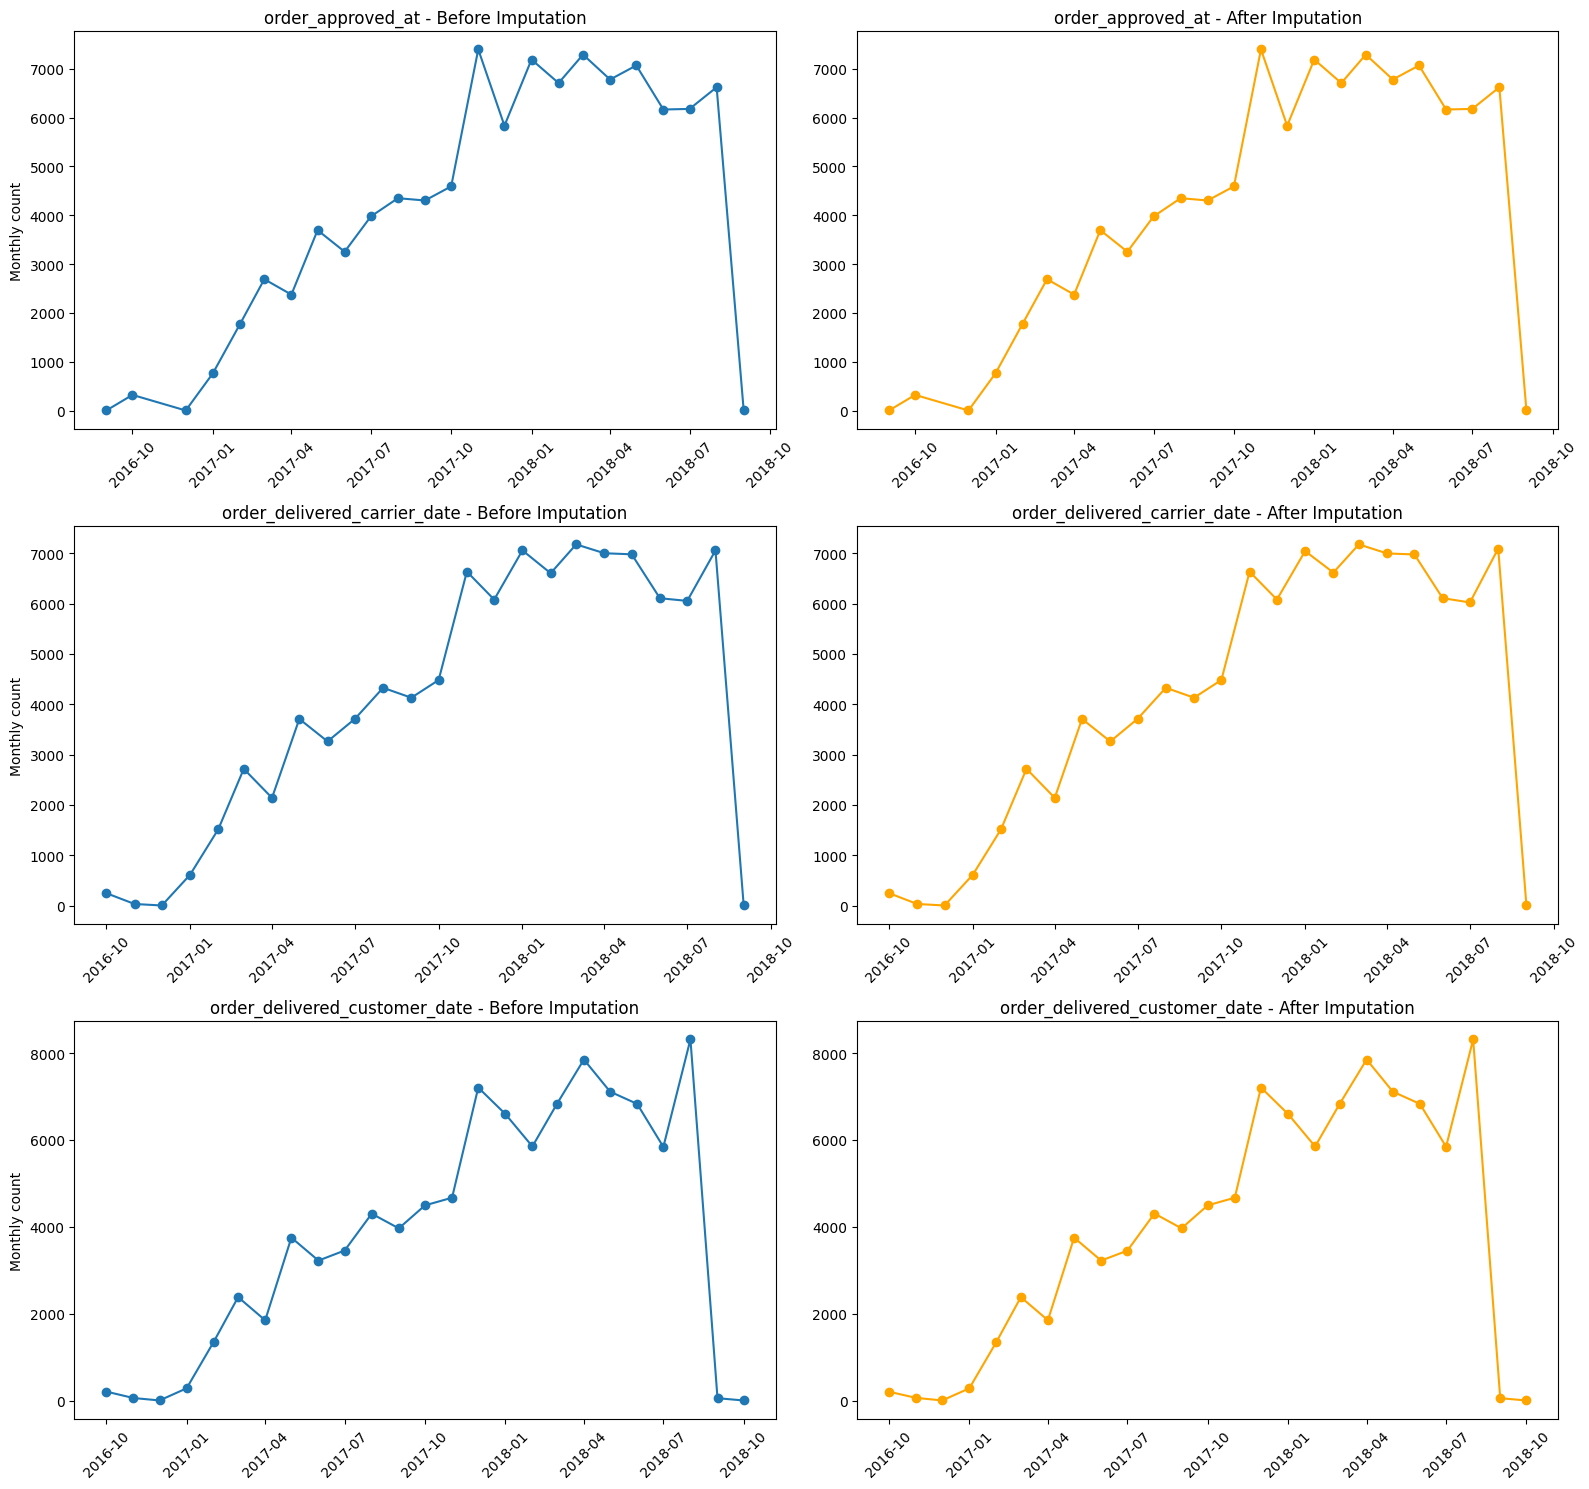

In [641]:
date_cols = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]

orders_original[date_cols] = orders_original[date_cols].apply(
    lambda col: pd.to_datetime(col, errors="coerce")
)

missing_pct = pd.DataFrame({
    "Original (%)": orders_original[date_cols].isna().mean() * 100,
    "Cleaned (%)": orders[date_cols].isna().mean() * 100
}).round(2)

display(missing_pct)

fig, axes = plt.subplots(len(date_cols), 2, figsize=(16, 15), sharey=False)

for i, col in enumerate(date_cols):
    orig_dates = orders_original[col].dropna()
    imp_dates = orders[col].dropna()

    orig_counts = orig_dates.dt.to_period("M").value_counts().sort_index()
    imp_counts = imp_dates.dt.to_period("M").value_counts().sort_index()

    axes[i, 0].plot(orig_counts.index.to_timestamp(), orig_counts.values, marker="o")
    axes[i, 0].set_title(f"{col} - Before Imputation")
    axes[i, 0].set_ylabel("Monthly count")
    axes[i, 0].tick_params(axis="x", rotation=45)

    axes[i, 1].plot(imp_counts.index.to_timestamp(), imp_counts.values, marker="o", color="orange")
    axes[i, 1].set_title(f"{col} - After Imputation")
    axes[i, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Nhận xét: không làm thay đổi quá nhiều vẫn giữ được xu hướng

## Xuất file csv

In [642]:
from pathlib import Path

Path(out_dir).mkdir(parents=True, exist_ok=True)
orders.to_csv(Path(out_dir) / "cleaned_orders.csv", index=False)

# Seller

## Check data type

In [643]:
sellers.dtypes

seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

## Check duplicate

In [644]:
sellers[customers.duplicated()]

C:\Users\huynh\AppData\Local\Temp\ipykernel_5348\3562057272.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sellers[customers.duplicated()]


,seller_id,seller_zip_code_prefix,seller_city,seller_state


## Check null

In [645]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

## Xuất file CSV

In [646]:
sellers.to_csv(f'{out_dir}/cleaned_sellers.csv', index=False)